<a href="https://colab.research.google.com/github/VGozzi/vnl-2024-stats-machine-learning-mvp/blob/main/mvp_machine_learning_and_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Vitor Martins Gozzi  
**Matrícula:** 4052026000264  
**Data:** 04/07/2026  
**Dataset:** VNL 2024 Men's Stats — [Kaggle](https://www.kaggle.com/datasets/jonathanpmoyer/vnl-2024-mens-stats)  
**Tipo de problema:** Clusterização não supervisionada

## 1. Definição do Problema

## 1.1 Descrição do problema
No voleibol moderno de alto nível, a especialização tática é crucial para o funcionamento do jogo em si. Ele é estruturado em torno de **cinco posições principais**, cada uma com funções rigidamente coordenadas para o funcionamento da equipe:

* **Levantador:** Considerado o cérebro do time, é responsável pela estratégia de jogo, pela distribuição das jogadas e pela armação do ataque.

* **Ponteiro:** O jogador mais equilibrado entre todos, que atua tanto na linha de frente do ataque pelas extremidades, tanto quanto carrega grande responsabilidade na recepção de saques e na defesa.

* **Oposto:** Normalmente a principal força ofensiva da equipe, acionado para finalizar jogadas de alta potência e liberado das obrigações de recepção para focar no ataque.

* **Central:** O especialista em bloqueios no meio da rede e em ataques de velocidade (curto tempo).

* **Líbero:** O especialista defensivo do time, que atua exclusivamente no fundo de quadra (recepção e defesa) e possui restrições de regras que o impedem de sacar ou atacar.

Como cada posição exige competências específicas, os atletas desenvolvem um perfil estatístico de ações muito distinto. Um líbero acumulará um volume massivo de defesas e passes, enquanto um central se destacará em bloqueio. Essa disparidade gera uma hipótese natural: será que essas cinco funções táticas formam, grupos "geometricamente" distintos, a ponto de um algoritmo conseguir descobri-los sozinho, sem nunca ter acesso ao rótulo de posição?

Para investigar essa questão, utilizamos o conjunto de dados da **Volleyball Nations League (VNL) 2024**, torneio que reúne a elite do voleibol mundial. Este projeto é uma evolução direta de um MVP anterior de Análise Exploratória de Dados (EDA), no qual observamos visualmente que as métricas de volume de jogo separam as posições com grande clareza (os pairplots da seção 4 repetiram parte da análise feita anteriormente). Essa separação visual é justamente o que motiva a escolha de **clusterização não supervisionada** como abordagem: se os grupos já aparecem nitidamente na EDA, é razoável esperar que um algoritmo de agrupamento consiga recuperá-los organicamente.

## 1.2 Objetivo do MVP

O objetivo deste MVP é aplicar e avaliar algoritmos de **clusterização não supervisionada** (K-Means, DBSCAN e clusterização hierárquica/HCA) sobre o perfil estatístico de volume de jogo dos atletas da VNL 2024, investigando até que ponto a estrutura geométrica intrínseca dos dados é suficiente para reconstruir, de forma totalmente orgânica, as cinco posições táticas do voleibol sem o uso de rótulos durante o treinamento.

A posição real de cada atleta (`Position`) é mantida exclusivamente como referência externa **após** a formação dos clusters, para medir, via Adjusted Rand Index (ARI), o quão bem a partição encontrada automaticamente coincide com a organização tática real do esporte.

## 1.3 Tipo de problema

* **Tipo escolhido:** Clusterização não supervisionada (*K-Means*, *DBSCAN* e clusterização hierárquica/*HCA*).
* **Justificativa:** A Análise Exploratória de Dados (seção 4) indicou uma separabilidade visual forte entre as posições. Os pairplots das variáveis `p_v_*` mostram grupos bem distintos, com pouca sobreposição entre a maioria das posições. Essa evidência visual motiva diretamente o uso de clusterização: se os grupos já são discerníveis a olho nu em duas dimensões, é razoável esperar que algoritmos formais de agrupamento, operando no espaço completo de seis dimensões, consigam recuperá-los de forma não supervisionada. O problema consiste, portanto, em avaliar se os clusters formados por cada algoritmo reproduzem as cinco posições táticas reais, usando o ARI e o Silhouette Score como métricas de validação.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses:**

1. **K-Means (k=5):** As seis features de volume relativo (`p_v_*`) produzem clusters suficientemente compactos e separados para que o K-Means, fixando `k=5` (uma para cada posição tática), atinja ARI $> 0,70$ contra os rótulos reais. Espera-se que Levantador e Líbero sejam recuperados com pureza quase total (por terem discriminadores praticamente exclusivos: `p_v_Set` e `p_v_Receive`), enquanto os poucos erros devem se concentrar na fronteira entre Oposto, Ponteiro e Central, posições que compartilham o volume de ataque.

2. **DBSCAN:** Devido à variação de densidade entre as posições (Ponteiro é numeroso e difuso no espaço de features; Líbero é compacto mas minoritário), espera-se que o DBSCAN tenha dificuldade em recuperar as 5 posições de forma limpa. Mesmo que encontre um número de clusters próximo de 5, deve classificar uma fração não desprezível dos atletas como ruído e atingir ARI inferior ao K-Means, com os descartes concentrados na zona de fronteira entre Oposto, Ponteiro e Central.

3. **HCA (clusterização hierárquica aglomerativa):** Com o linkage adequado (testado via busca entre `ward`, `complete`, `average` e `single`), a HCA atinge ARI $> 0,70$ com `k=5`, em desempenho comparável ao K-Means. Além disso, o dendrograma resultante deve refletir a proximidade tática esperada: Levantador e Líbero se separando do restante em alturas de fusão elevadas, enquanto Oposto, Ponteiro e Central se fundem em alturas mais baixas, confirmando a sobreposição estatística já observada na EDA.

**Critérios de Sucesso**
* **Métricas principais:** **ARI** (*Adjusted Rand Index*), para medir a concordância entre os clusters encontrados e as posições reais, e **Silhouette Score**, para medir a coesão interna dos clusters de forma totalmente independente dos rótulos.
* **Justificativa metodológica:** o ARI corrige a concordância ao acaso, sendo a métrica padrão para comparar uma partição não supervisionada contra um rótulo conhecido. O Silhouette complementa essa avaliação ao não depender de rótulo algum, servindo também para escolher o número de clusters (`k`), os hiperparâmetros de densidade (`eps`, `min_samples`) ou o critério de linkage da HCA de forma puramente intrínseca.
* **Resultados mínimos esperados:** **ARI $> 0,70$** para K-Means e HCA com `k=5`. Para o DBSCAN, o critério de sucesso é qualitativo: confirmar (ou refutar) a dificuldade prevista na Hipótese 2.
* **Restrições práticas e robustez:** padronização (`StandardScaler`) ajustada sobre o mesmo conjunto de dados usado na clusterização, evitando que variáveis com maior variância (como `p_v_Set`) dominem as métricas de distância.

# 2. Ambiente, bibliotecas e reprodutibilidade

## 2.1 Dependências adicionais

Além do ecossistema científico padrão (`pandas`, `numpy`, `scikit-learn`, `matplotlib`/`seaborn`), este projeto depende da biblioteca [`kagglehub`](https://pypi.org/project/kagglehub/), utilizada exclusivamente para o download programático do dataset diretamente do Kaggle — garantindo reprodutibilidade total sem a necessidade de configuração manual de credenciais de API.

In [ ]:
# 1. Bibliotecas padrão do Python
import os
import sys
import time
import random
import warnings

# 2. Manipulação e análise de dados
import pandas as pd
import numpy as np
import math

# 3. Visualização de dados e customização de gráficos
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# 4. Download programático do dataset do Kaggle
import kagglehub

# 5. Scikit-Learn: Pré-processamento
from sklearn.preprocessing import StandardScaler

# 6. Scikit-Learn: Clusterização, Redução de Dimensionalidade e Métricas
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score

# 7. SciPy: dendrograma da clusterização hierárquica
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage

warnings.filterwarnings("ignore")

SEED = 99
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 99


# 3. Seleção e carga dos dados


## 3.1 Fonte dos dados
O conjunto de dados selecionado para este projeto intitula-se **VNL 2024 Men's Stats**, hospedado e extraído publicamente da plataforma Kaggle através do link oficial: [Jonathan Moyer - VNL 2024 Men's Stats](https://www.kaggle.com/datasets/jonathanpmoyer/vnl-2024-mens-stats).

### Detalhes técnicos e fragmentação original:
A base de dados consolida as estatísticas oficiais de desempenho esportivo coletadas pela Federação Internacional de Voleibol (FIVB) durante a Volleyball Nations League (VNL) de 2024. Como mapeado no trabalho anterior, o ecossistema original dos dados encontra-se fragmentado em **8 arquivos independentes no formato `.csv`**, correspondendo a cada um dos fundamentos táticos e cadastros dos atletas:
1.  `VNL2024Men_Players.csv` (Dados cadastrais e posições oficiais dos atletas)
2.  `VNL2024Men_Attackers.csv` (Estatísticas detalhadas de ataque)
3.  `VNL2024Men_Diggers.csv` (Estatísticas detalhadas de defesa)
4.  `VNL2024Men_Blockers.csv` (Estatísticas detalhadas de bloqueio)
5.  `VNL2024Men_Receivers.csv` (Estatísticas detalhadas de recepção de saque)
6.  `VNL2024Men_Servers.csv` (Estatísticas detalhadas de saque)
7.  `VNL2024Men_Setters.csv` (Estatísticas detalhadas de levantamento)
8.  `VNL2024Men_Scorers.csv` (Pontuação geral agregada)

### Justificativa de escolha e continuidade do MVP:
A escolha deste conjunto justifica-se por fornecer o cenário empírico perfeito para investigar se as "assinaturas estatísticas" que diferenciam as 5 posições táticas do voleibol moderno (sistema tático 5x1) (Levantador - `S`, Líbero - `L`, Central - `MB`, Ponteiro - `OH` e Oposto - `O`). Tomando os achados do MVP anterior, **focamos nossa modelagem exclusivamente nos volumes totais de ações de cada fundamento**. A exploração anterior provou matematicamente que avaliar os dados pelas métricas de eficiência técnica resulta em uma altíssima sobreposição entre as diferentes posições, não se comportando como estatísticas robustas ou discriminantes para modelos de Clusterização. Em contrapartida, o volume bruto acumulado é onde reside a verdadeira identidade de cada função tática, gerando padrões quantitativos consistentes e ideais para que algoritmos de clusterização consigam separar os atletas em grupos coerentes, sem qualquer acesso ao rótulo de posição durante o agrupamento.

## 3.2 Carga e reconstrução dos dados

O carregamento do dataset é efetuado diretamente do repositório público do Kaggle por meio da biblioteca `kagglehub`.

O pipeline abaixo reconstrói a estrutura unificada dos dados a partir dos 8 arquivos fragmentados originais. O procedimento adota a tabela cadastral de atletas (`VNL2024Men_Players.csv`) como nossa base primária e realiza sucessivas operações de fusão (*Left Joins*) utilizando como chave composta os atributos textuais `Name` (Nome) e `Team` (Seleção).

Em alinhamento direto com as conclusões do MVP anterior, isolamos exclusivamente as colunas identificadoras, a variável-alvo (`Position`) e as 6 variáveis de volume total de ações por fundamento, tratando os sufixos duplicados gerados nas junções.

In [ ]:
try:
    # Faz o download programático da versão mais recente do dataset via API do kagglehub
    path = kagglehub.dataset_download("jonathanpmoyer/vnl-2024-mens-stats")

    # Lista os arquivos disponíveis no diretório baixado para auditoria de carga
    print("Arquivos detectados no diretório do dataset:", os.listdir(path))

#TODO: preciso fazer um processo para pegar o csv caso n funcione o kagglehub
except Exception as e:
    path = "https://raw.githubusercontent.com/VGozzi/vnl-2024-stats-machine-learning-mvp/main/dataset"
    print(f"kagglehub indisponível ({e}). Usando fallback do GitHub: {path}")

Using Colab cache for faster access to the 'vnl-2024-mens-stats' dataset.
Arquivos detectados no diretório do dataset: ['VNL2024Men_Diggers.csv', 'VNL2024Men_Receivers.csv', 'VNL2024Men_Servers.csv', 'VNL2024Men_Scorers.csv', 'VNL2024Men_Attackers.csv', 'VNL2024Men_Blockers.csv', 'VNL2024Men_Players.csv', 'VNL2024Men_Setters.csv']


In [ ]:

# Carrega todos os sub-datasets de estatísticas da VNL 2024 Masculina
dfs_bruto = [
    pd.read_csv(f'{path}/VNL2024Men_Players.csv'),
    pd.read_csv(f'{path}/VNL2024Men_Attackers.csv', encoding='latin1'),
    pd.read_csv(f'{path}/VNL2024Men_Diggers.csv'),
    pd.read_csv(f'{path}/VNL2024Men_Blockers.csv'),
    pd.read_csv(f'{path}/VNL2024Men_Receivers.csv'),
    pd.read_csv(f'{path}/VNL2024Men_Servers.csv'),
    pd.read_csv(f'{path}/VNL2024Men_Setters.csv'),
    pd.read_csv(f'{path}/VNL2024Men_Scorers.csv')
]

# Consolida os arquivos fragmentados através de Joins consecutivos pelas chaves biunívocas
df_bruto = dfs_bruto[0].copy()
for i in dfs_bruto[1:]:
    df_bruto = pd.merge(
        df_bruto,
        i,
        on=['Name', 'Team'],
        how='left'
    )

# Seleciona estritamente as colunas identificadoras, o target e os volumes totais
colunas_totais = [
    'Team',
    'Name',
    'Position',
    'Tot_Attack',    # Total de ações de ataque tentadas/efetuadas
    'T_Dig',         # Total de defesas de campo
    'Tot_Block_x',   # Total de toques e pontos de bloqueio
    'Tot_Receive',   # Total de ações de recepção de saque (passe)
    'Tot_Serve_x',   # Total de saques executados
    'Tot_Set'        # Total de levantamentos/armações realizados
]

df_fundamentos = df_bruto[colunas_totais].copy()


# Mapeamento de nomes das posições
mapeamento_posicoes = {
    'OH': 'Ponteiro',
    'L': 'Libero',
    'S': 'Levantador',
    'MB': 'Central',
    'O': 'Oposto'
}

# Aplicar a substituição na coluna 'Position'
df_fundamentos['Position'] = df_fundamentos['Position'].replace(mapeamento_posicoes)

# Limpeza de nomenclatura: remove os sufixos temporários '_x' herdados dos merges
df_fundamentos.columns = [col.replace('_x', '') for col in df_fundamentos.columns]

# Exibe a amostragem inicial do dataframe consolidado pronto para modelagem
df_fundamentos

,Team,Name,Position,Tot_Attack,T_Dig,Tot_Block,Tot_Receive,Tot_Serve,Tot_Set
0,ARG,Armoa Morel,Ponteiro,NaN,NaN,NaN,NaN,NaN,NaN
1,ARG,Conte,Ponteiro,211.0,76.0,63.0,180.0,118.0,48.0
2,ARG,Danani,Libero,0.0,188.0,0.0,233.0,2.0,54.0
3,ARG,De Cecco,Levantador,24.0,75.0,61.0,5.0,135.0,966.0
4,ARG,Gallego,Central,5.0,2.0,5.0,0.0,6.0,0.0
...,...,...,...,...,...,...,...,...,...
299,USA,Russell,Ponteiro,52.0,21.0,12.0,60.0,30.0,4.0
300,USA,Smith,Central,18.0,10.0,26.0,4.0,19.0,3.0
301,USA,Tuaniga,Levantador,3.0,13.0,12.0,1.0,16.0,173.0
302,USA,Wetter,Ponteiro,3.0,2.0,3.0,1.0,4.0,0.0


## 3.3 Visão geral do dataset
O conjunto de dados resultante apresenta o formato inicial de **304 linhas (instâncias) e 9 colunas (atributos)**.

O dataset é composto por duas variáveis textuais de identificação (`Team` e `Name`), uma variável categórica nominal (`Position`) que indica a posição tática oficial do atleta e será usada apenas como referência de validação após a clusterização, e 6 variáveis numéricas contínuas (`Tot_Attack`, `T_Dig`, `Tot_Block`, `Tot_Receive`, `Tot_Serve`, `Tot_Set`) que mensuram o volume bruto de ações físicas executadas por cada atleta.

In [ ]:
print(f"Formato inicial do dataset: {df_fundamentos.shape[0]} linhas e {df_fundamentos.shape[1]} colunas.")

Formato inicial do dataset: 304 linhas e 9 colunas.


In [ ]:
# Verifica se existem linhas duplicadas no dataset
total_duplicadas = df_fundamentos.duplicated().sum()
print(f"\nTotal de registros completamente duplicados: {total_duplicadas}")
if total_duplicadas > 0:
    duplicados = df_fundamentos[df_fundamentos.duplicated(keep=False)]
    print(duplicados)

# Remove duplicados mantendo a primeira ocorrência
df_fundamentos = df_fundamentos.drop_duplicates()


Total de registros completamente duplicados: 1
   Team        Name Position  Tot_Attack  T_Dig  Tot_Block  Tot_Receive  \
89  FRA  Chinenyeze  Central        23.0    2.0       13.0          1.0   
90  FRA  Chinenyeze  Central        23.0    2.0       13.0          1.0   

    Tot_Serve  Tot_Set  
89       17.0      0.0  
90       17.0      0.0  


In [ ]:
# Colunas quantitativas de interesse
cols = ['Tot_Attack', 'T_Dig', 'Tot_Block', 'Tot_Receive', 'Tot_Serve', 'Tot_Set']

print(f"\nTotal de registros inicial: {len(df_fundamentos)}")

# Substitui NaNs por 0 (Tratamento de nulos parciais)
df_clean = df_fundamentos.copy()
df_clean[cols] = df_clean[cols].fillna(0)

# Identifica linhas totalmente zeradas.
# Se a soma dos valores absolutos for 0, a linha inteira é inválida
linhas_vazias = df_clean[cols].abs().sum(axis=1) == 0

# Filtra o DataFrame mantendo apenas quem tem dados úteis
df_clean = df_clean[~linhas_vazias].copy()

print("\n--- Pós-Tratamento ---")
print(f"Total de registros removidos (nulos ou zerados): {linhas_vazias.sum()}")
print(f"Total de registros limpos para modelagem: {len(df_clean)}")
print(f"Dimensões finais do dataset: {df_clean.shape}\n")


Total de registros inicial: 303

--- Pós-Tratamento ---
Total de registros removidos (nulos ou zerados): 21
Total de registros limpos para modelagem: 282
Dimensões finais do dataset: (282, 9)



> ### Tratamento de valores ausentes e de perfis vazios

> Para garantir a integridade da modelagem, os registros foram tratados de acordo com a extensão e o significado técnico das suas ausências:

> - **Perfis vazios (Removido):** Linhas que apresentavam ausência total de dados — seja por omissão de registro (NaN em todas as colunas) ou por zeragem integral (0 em todos os fundamentos) — foram descartadas. Esses casos indicam que o atleta não teve participação ativa ou que seus dados não foram coletados, não gerando nenhum sinal tático aproveitável.

> - **Ausências Parciais (Imputação por Zero):** Registros com omissões em apenas alguns fundamentos foram mantidos, e as lacunas foram preenchidas com zero. No contexto do voleibol, a ausência de um registro é informativa: um levantador com Tot_Receive = NaN, por exemplo, provavelmente não executou recepções no jogo. Imputar zero preserva essa característica tática real em vez de tratá-la como um erro de sistema.

> Como os dados nulos parciais são convertidos em zero antes da validação final, a estratégia elimina o risco de linhas "mistas" (combinação de NaN e zeros) passarem despercebidas. Isso consolida a limpeza em um único fluxo e garante que nenhuma divisão por zero ($0 \div 0$) ocorra nas etapas subsequentes.

In [ ]:
# Data Set tratado
df_clean.info()

print("\nAmostragem aleatória de 5 registros do dataset tratado:")
display(df_clean.sample(5, random_state=SEED))

<class 'pandas.core.frame.DataFrame'>
Index: 282 entries, 1 to 303
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Team         282 non-null    object 
 1   Name         282 non-null    object 
 2   Position     282 non-null    object 
 3   Tot_Attack   282 non-null    float64
 4   T_Dig        282 non-null    float64
 5   Tot_Block    282 non-null    float64
 6   Tot_Receive  282 non-null    float64
 7   Tot_Serve    282 non-null    float64
 8   Tot_Set      282 non-null    float64
dtypes: float64(6), object(3)
memory usage: 22.0+ KB

Amostragem aleatória de 5 registros do dataset tratado:


,Team,Name,Position,Tot_Attack,T_Dig,Tot_Block,Tot_Receive,Tot_Serve,Tot_Set
157,ITA,Michieletto,Ponteiro,197.0,46.0,49.0,156.0,133.0,38.0
50,BUL,Petrov,Ponteiro,6.0,2.0,3.0,8.0,2.0,2.0
188,NED,De Weijer,Levantador,0.0,2.0,1.0,0.0,2.0,23.0
169,JPN,Kai,Ponteiro,130.0,39.0,25.0,135.0,81.0,15.0
3,ARG,De Cecco,Levantador,24.0,75.0,61.0,5.0,135.0,966.0


# 4. Análise Exploratória dos Dados (EDA)

Nesta seção, investigamos a distribuição da posição e o comportamento dos atributos de volume de jogo — tanto os absolutos (`Tot_*`) quanto os normalizados após a engenharia de features (`p_v_*`), segmentados por cada posição tática. O objetivo é validar visualmente as assinaturas estatísticas de cada função em quadra, além de diagnosticar potenciais anomalias, como desbalanceamento de classes ou vieses amostrais, garantindo a integridade dos dados antes da etapa de modelagem.

## 4.1 Funções auxiliares

Esta seção concentra as funções de visualização reutilizadas ao longo da análise exploratória (distribuição do target, matriz de histogramas por posição e pairplots).

In [ ]:
def plot_distribuicao_posicao(df, cores_posicao):
    """Gráfico de barras com contagem de atletas por posição."""
    ordem = df['Position'].value_counts().index
    ax = sns.countplot(data=df, x='Position', order=ordem, palette=cores_posicao, hue='Position', legend=False)

    # Anota o valor exato no topo de cada barra
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12, fontweight='bold')

    # Definição de Títulos e labels
    plt.title('Distribuição da Quantidade de Atletas por Posição', fontsize=16, pad=10)
    plt.xlabel('Posição Tática', fontsize=12)
    plt.ylabel('Número de Jogadores', fontsize=12)
    ax.set_ylim(0, df['Position'].value_counts().max() * 1.1)
    plt.show()

def plot_matriz_atributos(df, cores_posicao, posicoes_ordem=None):
    """Matriz de histogramas comparando todos os atributos numéricos por posição."""
    if posicoes_ordem is None:
        posicoes_ordem = list(cores_posicao.keys())

    atributos = df.select_dtypes(include=['number']).columns
    fig, axes = plt.subplots(len(atributos), len(posicoes_ordem),
                             figsize=(4 * len(posicoes_ordem), len(atributos) * 4), squeeze=False)
    sns.set_theme(style="whitegrid")

    # Itera sobre cada atributo e posição para preencher a matriz
    for row_idx, atri in enumerate(atributos):
        for col_idx, pos in enumerate(posicoes_ordem):
            ax = axes[row_idx, col_idx]
            dados_celula = df[df['Position'] == pos][atri].dropna()

            if not dados_celula.empty:
                media, mediana = dados_celula.mean(), dados_celula.median()

                # Histograma com KDE e linhas de média e mediana
                sns.histplot(x=dados_celula, bins=10, kde=True, ax=ax,
                             color=cores_posicao.get(pos, 'gray'), alpha=0.6, edgecolor='white')
                ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média: {media:.2f}')
                ax.axvline(mediana, color='black', linestyle=':', linewidth=2, label=f'Mediana: {mediana:.2f}')
                ax.legend(loc='upper right', fontsize=9, frameon=True)

            # Títulos e labels apenas nas bordas da matriz
            if row_idx == 0: ax.set_title(f'Posição: {pos}', fontsize=16, fontweight='bold', pad=15)
            ax.set_ylabel('Frequência' if col_idx == 0 else '', fontsize=12, fontweight='bold')

    plt.tight_layout(pad=3.0)
    plt.show()

def plot_boxplots_atributos(df, cores_posicao, posicoes_ordem=None, cols_per_row=3):
    """Grade de boxplots para todos os atributos numéricos, comparados por posição."""
    atributos = df.select_dtypes(include=['number']).columns
    if posicoes_ordem is None: posicoes_ordem = ['Ponteiro', 'Central', 'Levantador', 'Oposto', 'Libero']

    # Calcula o número de linhas necessárias para acomodar todos os atributos
    num_rows = math.ceil(len(atributos) / cols_per_row)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(20, num_rows * 5), constrained_layout=False)
    axes_flat = axes.flatten() if len(atributos) > 1 else [axes]

    # Plota um boxplot por atributo
    for i, atri in enumerate(atributos):
        ax = axes_flat[i]
        sns.boxplot(data=df, x='Position', y=atri, order=posicoes_ordem, ax=ax,
                    palette=cores_posicao, hue='Position', legend=False, fliersize=4, fill=True)
        ax.set_title(f'Distribuição: {atri}', fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel('Posição', fontsize=10)
        ax.set_ylabel('Valores Brutos', fontsize=10)
        sns.despine(ax=ax, left=True)

    # Remove eixos vazios que sobram na grade
    for j in range(i + 1, len(axes_flat)): fig.delaxes(axes_flat[j])

    plt.tight_layout(pad=3.0)
    plt.show()

def build_pairplot(x_vars, y_vars, titulo, df, posicoes_ordem, cores_posicao):
    """ Recorte do PairPlot completo dos atributos para cada variável (p_v_* e P_ef_*)."""
    sns.set_theme(style="whitegrid")
    # Gerar o pairplot cortado para a variaveis selecionadas
    pp = sns.pairplot(
        df,
        x_vars=x_vars,
        y_vars=y_vars,
        hue='Position',
        hue_order=posicoes_ordem,
        palette=cores_posicao,
        diag_kind='kde' if x_vars == y_vars else None,
        height=3.5,
        aspect=1.1,
        plot_kws={'alpha': 0.5, 's': 120, 'edgecolor': 'w', 'linewidth': 0.5},
        diag_kws={'fill': True, 'alpha': 0.4}
    )

    # Criar handles para a legenda
    legend_elements = [
        mpatches.Patch(color=cores_posicao.get(pos, 'gray'), label=pos)
        for pos in posicoes_ordem
    ]

    # Customização de legendas label's e afins
    for i, y_var in enumerate(y_vars):
        for j, x_var in enumerate(x_vars):
            ax = pp.axes[i, j]
            if ax is None: continue
            ax.tick_params(labelbottom=True, labelleft=True, labelsize=8)
            if i == j and x_var == y_var:
                ax.set_xlabel(x_var.replace('_', ' ').title(), fontsize=10, fontweight='bold')
                ax.set_ylabel('')
            else:
                ax.set_xlabel(x_var.replace('_', ' ').title(), fontsize=10, fontweight='bold')
                ax.set_ylabel(y_var.replace('_', ' ').title(), fontsize=10, fontweight='bold')
            ax.xaxis.label.set_visible(True)
            ax.yaxis.label.set_visible(True)
            ax.legend(handles=legend_elements, loc='upper right',
                      fontsize=7, frameon=True, framealpha=0.6)
            ax.grid(True, linestyle='--', alpha=0.3)
            ax.set_axisbelow(True)

    # Ajustes os subplots
    pp.fig.suptitle(titulo, fontsize=26, fontweight='bold', y=0.88)
    plt.subplots_adjust(top=0.85, hspace=0.35, wspace=0.3, left=0.07, right=0.97)
    if pp._legend:
        pp._legend.remove()

    plt.show()

## 4.2 Visualização das distribuições por posição


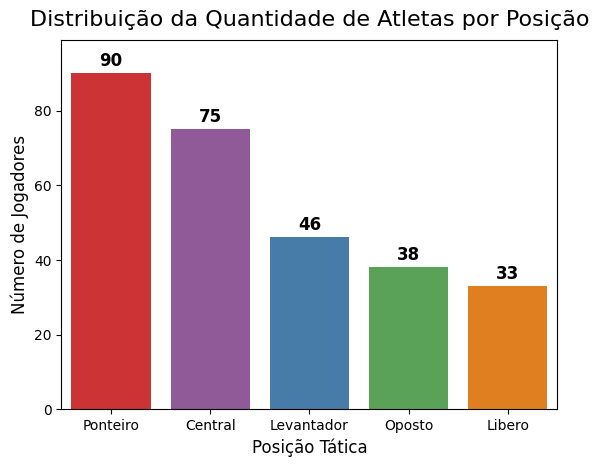

In [ ]:
# Mapeamento manual para garantir as cores para cada atributo
paleta = sns.color_palette('Set1')
cores_posicao = {
    'Ponteiro': paleta[0],    # Vermelho
    'Levantador':  paleta[1], # Azul
    'Oposto':  paleta[2],     # Verde
    'Central': paleta[3],     # Roxo
    'Libero':  paleta[4]      # Laranja
}

# Plota as distribução da quantidade de atletas por Posição
plot_distribuicao_posicao(df_clean, cores_posicao)

> O gráfico de distribuição revela uma disparidade numérica entre as posições, com predominância de Ponteiros (OH) e Centrais (MB). Esse comportamento é inerente à dinâmica do voleibol, que utiliza dois atletas de cada uma dessas funções em quadra, contra apenas um Levantador (S), Oposto (O) e Líbero (L). A ligeira superioridade quantitativa de Ponteiros em relação a Centrais, e de Levantadores em relação a Líberos, reflete na maior exigência desses jogadores em quadra, sendo necessário um maior volume de substituições nessas funções específicas.

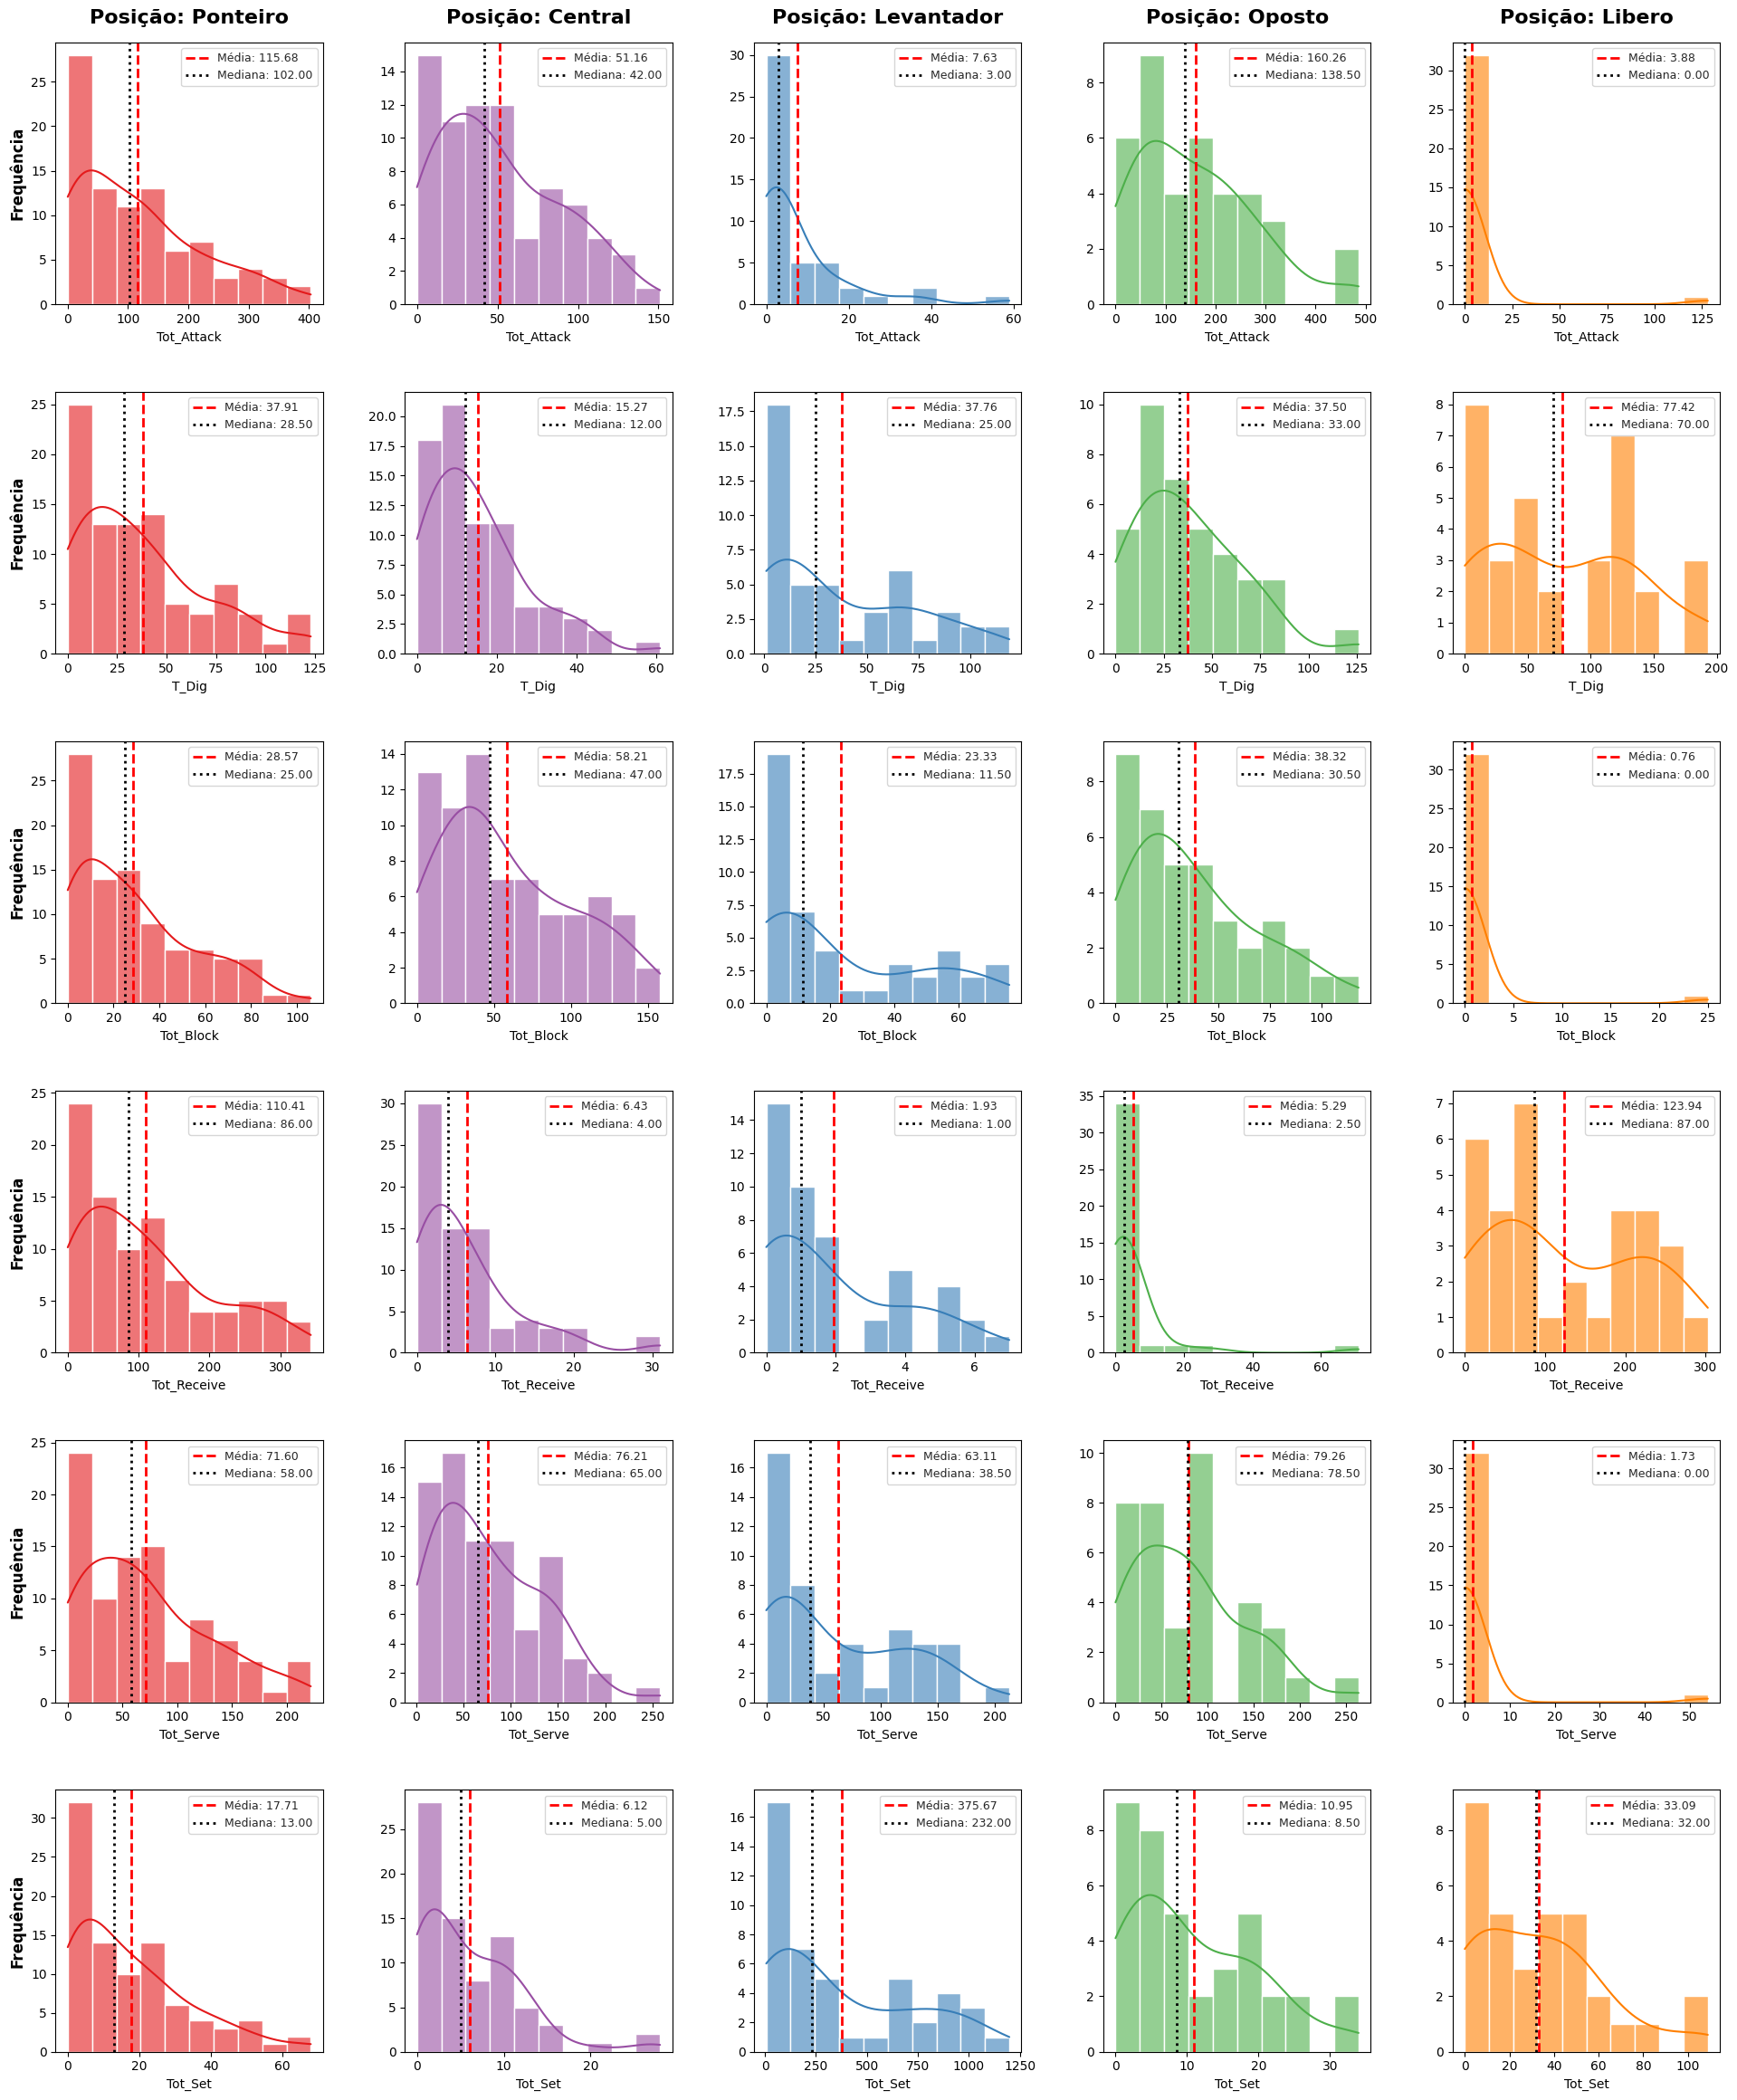

In [ ]:
ordem = ['Ponteiro', 'Central', 'Levantador', 'Oposto', 'Libero']

# Escalas dos eixos X e Y são independentes por gráfico, priorizando
# a visualização da forma de cada distribuição em vez da comparação direta de magnitude.
plot_matriz_atributos(df_clean, cores_posicao, ordem)

> A análise da matriz de distribuição revela uma forte concentração de registros próximos à origem, reflexo direto da **disparidade de minutagem** entre atletas titulares e reservas. Esse fenômeno evidencia um viés de amostragem condicionado pela participação em jogo, resultando em uma distribuição com **assimetria positiva** (a média se desloca à direita da mediana, indicando um alongamento da cauda direita da distribuição). Essa assimetria compromete diretamente a capacidade de distinção entre posições, pois um reserva com poucos toques produz um perfil estatístico quase nulo, independente da sua função tática.

### 4.3 Feature engineering

Para mitigar o viés de minutagem identificado acima e tornar as estatísticas comparáveis entre jogadores, utilizamos a **proporção relativa do fundamento** (`p_v_*`): a proporção de cada tipo de ação sobre o total de ações do jogador. Essa métrica não mede qualidade técnica, e sim a participação relativa do atleta naquele fundamento, atenuando o efeito do tempo de jogo.

In [ ]:
# Calcula o total de todas as ações de um jogador
df_clean['Total_Geral'] = df_clean[cols].sum(axis=1)
df_clean.head()

# Cria as novas colunas de volume relativo (p_v_*)
for col in cols:
    nome_base = col.replace('Tot_', '').replace('T_', '')
    nome_nova_col = f'p_v_{nome_base}'
    df_clean[nome_nova_col] = df_clean[col] / df_clean['Total_Geral']

# Seleciona apenas as colunas identificadoras + as novas features p_v
colunas_dados = [col for col in df_clean.columns if col.startswith('p_v_')]
colunas_finais = ['Team', 'Name', 'Position'] + colunas_dados
df_clean2 = df_clean[colunas_finais].dropna(subset=colunas_dados, how='all').copy()

print(f"Dimensões finais do df_final: {df_clean2.shape[0]} atletas × {df_clean2.shape[1]} colunas")
display(df_clean2.sample(5, random_state=SEED))


Dimensões finais do df_final: 282 atletas × 9 colunas


,Team,Name,Position,p_v_Attack,p_v_Dig,p_v_Block,p_v_Receive,p_v_Serve,p_v_Set
157,ITA,Michieletto,Ponteiro,0.318255,0.074313,0.079160,0.252019,0.214863,0.061389
50,BUL,Petrov,Ponteiro,0.260870,0.086957,0.130435,0.347826,0.086957,0.086957
188,NED,De Weijer,Levantador,0.000000,0.071429,0.035714,0.000000,0.071429,0.821429
169,JPN,Kai,Ponteiro,0.305882,0.091765,0.058824,0.317647,0.190588,0.035294
3,ARG,De Cecco,Levantador,0.018957,0.059242,0.048183,0.003949,0.106635,0.763033


## 4.4 Dicionário de dados

A tabela a seguir apresenta a especificação técnica dos atributos utilizados na modelagem, após o processo de normalização (*Feature Engineering*), onde as métricas de volume absoluto foram convertidas em frequências relativas.

| Atributo | Tipo / Escala | Descrição | Utilizado? | Justificação Técnica |
| :--- | :--- | :--- | :---: | :--- |
| **Team** | `string`<br>Nominal | Seleção nacional do<br>atleta na VNL 2024. | **Não** | Metadado de identificação.<br>Evita sobreajuste (*overfitting*). |
| **Name** | `string`<br>Nominal | Nome oficial do atleta<br>na competição. | **Não** | Metadado de identificação.<br>Evita sobreajuste (*overfitting*). |
| **p_v_Attack** | `float64`<br>Razão [0-1] | Frequência relativa de ataques. | **Sim** | Define a carga ofensiva do atleta (ex: Opostos). |
| **p_v_Dig** | `float64`<br>Razão [0-1] | Frequência relativa de defesas. | **Sim** | Identifica especialistas defensivos (Líberos). |
| **p_v_Block** | `float64`<br>Razão [0-1] | Frequência relativa de bloqueios. | **Sim** | Assinatura tática distintiva do Central. |
| **p_v_Receive** | `float64`<br>Razão [0-1] | Frequência relativa de passes. | **Sim** | Identifica atletas com perfil de recepção. |
| **p_v_Serve** | `float64`<br>Razão [0-1] | Frequência relativa de saques. | **Sim** | Pondera o peso do saque no perfil tático. |
| **p_v_Set** | `float64`<br>Razão [0-1] | Frequência relativa de levantamentos. | **Sim** | Característica excludente do Levantador. |
| **Position** | `string`<br>Nominal | Posição tática (Ponteiro, Líbero, etc.) | **Não (apenas validação)** | Não é usada como feature; serve só para calcular o ARI após a clusterização. |

## 4.4 Plots e Análises


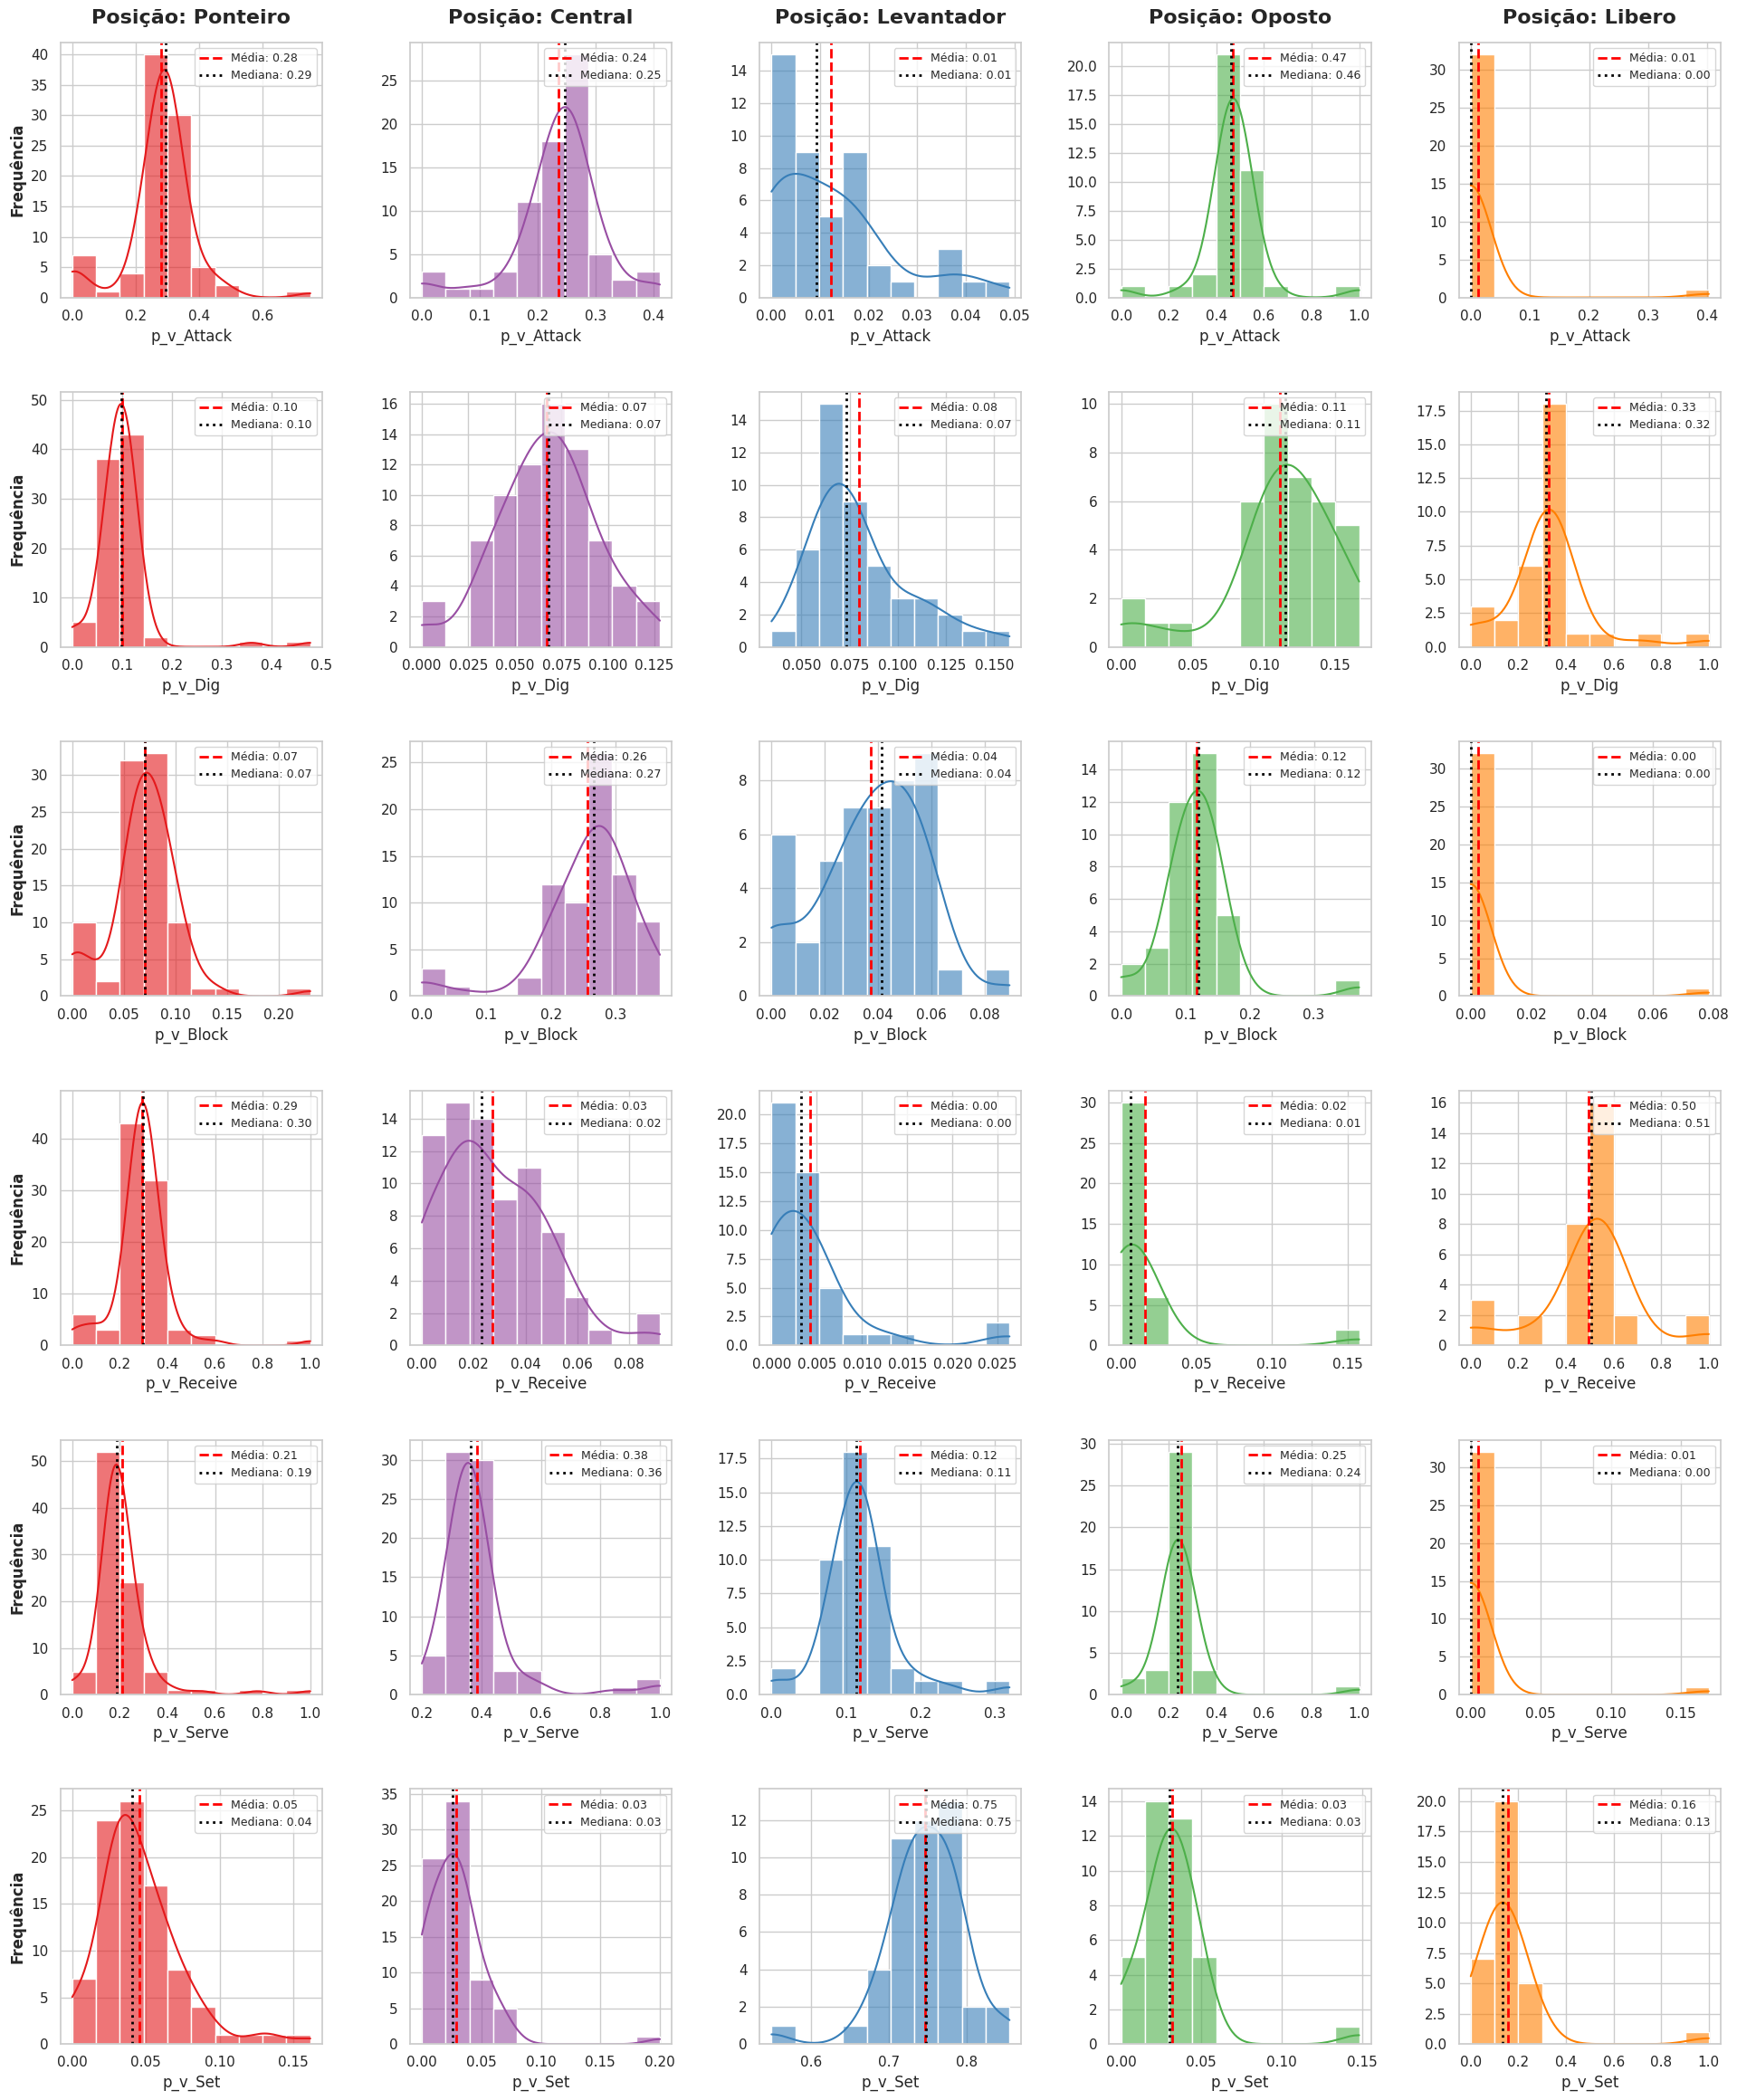

In [ ]:
# Optamos por manter as escalas dos eixos Y independentes por gráfico devido
# a ilegibilidade. Já no eixo X, o range é calculado sobre todas as posições do
# atributo, garantindo que a distribuição de cada posição seja comparável visualmente.
plot_matriz_atributos(df_clean2, cores_posicao, ordem)


> O efeito mais importante do feature engeenering que fizemos é justamente a redução do "viés do reservas" para as posições que de fato exercem aquele fundamento. Após o tratamento, como podemos ver no gráfico, essa assimetria se atenua, na qual as distribuições passam a se aproximar de formas mais simétricas e melhor interpretáveis.


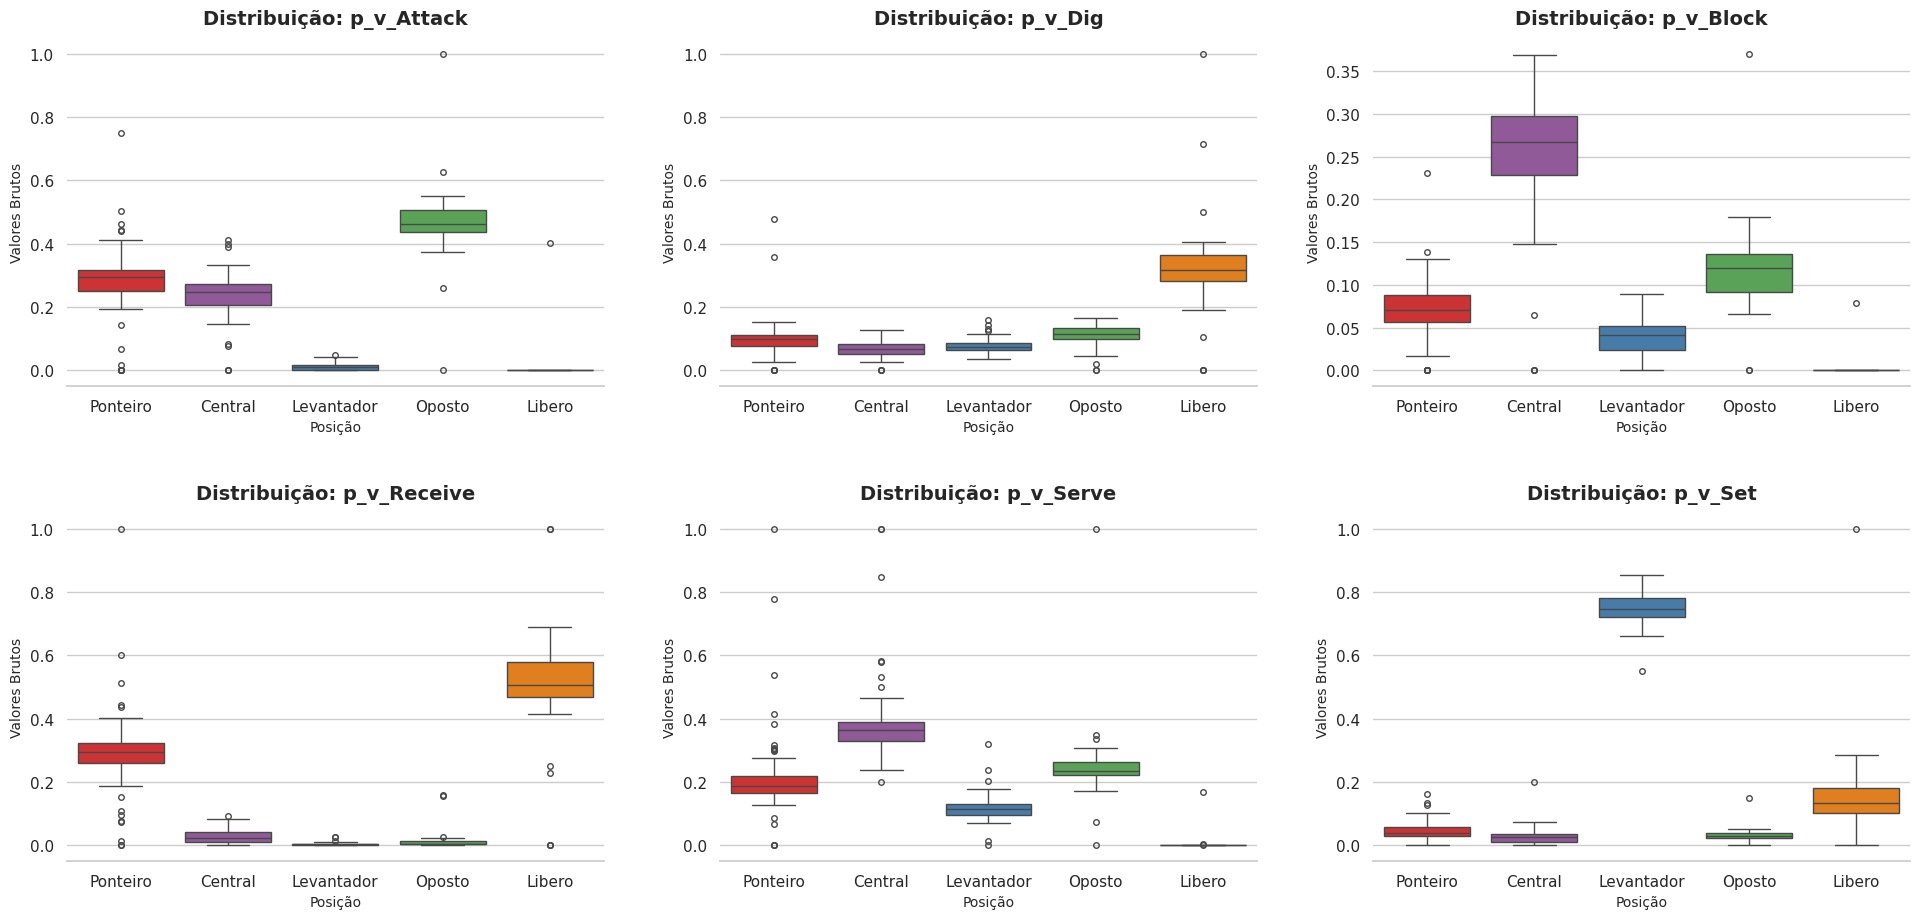

In [ ]:
# Mapeamento manual para garantir as cores para cada atributo
paleta = sns.color_palette('Set1')
cores_posicao = {
    'Ponteiro': paleta[0], # Vermelho
    'Levantador':  paleta[1], # Azul
    'Oposto':  paleta[2], # Verde
    'Central': paleta[3], # Roxo
    'Libero':  paleta[4]  # Laranja
}
plot_boxplots_atributos(df_clean2, cores_posicao=cores_posicao)

> Os boxplots acima mostram muitos outliers, mas eles **não têm todos a mesma natureza** — e essa distinção motiva o tratamento a seguir:

> **Outliers a preservar.** Muitos pontos extremos são a própria *assinatura* da posição: o `p_v_Set` alto de um levantador ou o `p_v_Receive` alto de um líbero são o sinal que o modelo deve capturar. O `p_v_Attack = 1.0` do gráfico é o oposto Sanchez B. (CUB), titular com 192 ações e perfil ofensivo puro.

> **Outliers a remover.** Outros aparecem na posição *errada* e são taticamente impossíveis: Central com `p_v_Serve = 1.0`, Ponteiro com `p_v_Receive = 1.0`, Líbero com `p_v_Dig = 1.0`. Surgem porque `p_v_*` é uma razão sobre o total de ações (`Total_Geral`), e denominador minúsculo gera proporções degeneradas. O Central `p_v_Serve = 1.0` é Kartev (BUL), com **uma única ação no torneio** (um saque): não é um "central sacador", é ruído.

A diferença entre os dois grupos está no volume de participação: **os perfis degenerados vêm todos de atletas com um numero pequeno de ações**. Por isso aplicamos um critério de participação mínima, removendo quem tem menos de 10 ações no torneio.

In [ ]:
# Limite de ações para aplicar o corte de outliers
LIMIAR_ACOES = 10

df_com_total = df_clean2.copy()
df_com_total['Total_Geral'] = df_clean.loc[df_com_total.index, 'Total_Geral']

# Diagnóstico: outliers extremos (algum p_v >= 0.5) por faixa de participação
print(f"{'Fundamento':<14}{'nº outliers':>12}{'a remover (<10)':>17}{'a preservar (>=10)':>20}")
print('─' * 63)
for c in colunas_dados:
    ext = df_com_total[df_com_total[c] >= 0.5]
    remover   = (ext['Total_Geral'] <  LIMIAR_ACOES).sum()
    preservar = (ext['Total_Geral'] >= LIMIAR_ACOES).sum()
    print(f"{c:<14}{len(ext):>12}{remover:>17}{preservar:>20}")

# Perfis degenerados: p_v = 1.0 com baixíssima participação
print("\nExemplos de perfis degenerados (p_v = 1.0 com pouquíssimas ações):")
degenerados = df_com_total[(df_com_total[colunas_dados] >= 0.999).any(axis=1)
                           & (df_com_total['Total_Geral'] < LIMIAR_ACOES)].copy()
degenerados['fundamento'] = degenerados[colunas_dados].idxmax(axis=1).str.replace('p_v_', '')
display(
    degenerados[['Name', 'Team', 'Position', 'fundamento', 'Total_Geral']]
    .sort_values('Total_Geral').reset_index(drop=True)
)

# Aplicação do filtro
mask_participacao = df_com_total['Total_Geral'] >= LIMIAR_ACOES
df_final = df_com_total[mask_participacao].drop(columns='Total_Geral').copy()

n_antes  = len(df_com_total)
n_depois = len(df_final)
print(f"\nAtletas antes do filtro : {n_antes}")
print(f"Atletas removidos       : {n_antes - n_depois} ({(n_antes - n_depois)/n_antes*100:.1f}%)")
print(f"Atletas após o filtro   : {n_depois}\n")

# Distribuição das posições: antes x depois do filtro
print("\nDistribuição das posições (proporção antes x depois do filtro):")
comparativo = pd.DataFrame({
    'antes (%)':    (df_com_total['Position'].value_counts(normalize=True) * 100).round(1),
    'depois (%)':   (df_final['Position'].value_counts(normalize=True) * 100).round(1),
})
display(comparativo)

Fundamento     nº outliers  a remover (<10)  a preservar (>=10)
───────────────────────────────────────────────────────────────
p_v_Attack              15                1                  14
p_v_Dig                  3                3                   0
p_v_Block                0                0                   0
p_v_Receive             23                3                  20
p_v_Serve               11                4                   7
p_v_Set                 47                2                  45

Exemplos de perfis degenerados (p_v = 1.0 com pouquíssimas ações):


,Name,Team,Position,fundamento,Total_Geral
0,Bardarov,BUL,Ponteiro,Receive,1.0
1,D. Kolev,BUL,Libero,Set,1.0
2,Kartev,BUL,Central,Serve,1.0
3,Gorguet,CUB,Libero,Receive,1.0
4,Currie,CAN,Libero,Receive,2.0
5,Cortesia,ITA,Central,Serve,2.0
6,Rinaldi,ITA,Ponteiro,Serve,3.0
7,Briggs,USA,Libero,Dig,5.0
8,Charles,CUB,Oposto,Serve,8.0



Atletas antes do filtro : 282
Atletas removidos       : 15 (5.3%)
Atletas após o filtro   : 267


Distribuição das posições (proporção antes x depois do filtro):


,antes (%),depois (%)
Position,,
Ponteiro,31.9,32.2
Central,26.6,27.0
Levantador,16.3,16.9
Oposto,13.5,13.9
Libero,11.7,10.1


> Com 15 atletas removidos (5,3%), as proporções entre posições permanecem praticamente inalteradas (maior variação: Líbero, 11,7% → 10,1%). A remoção eliminou os perfis degenerados sem desbalancear tanto as classes.

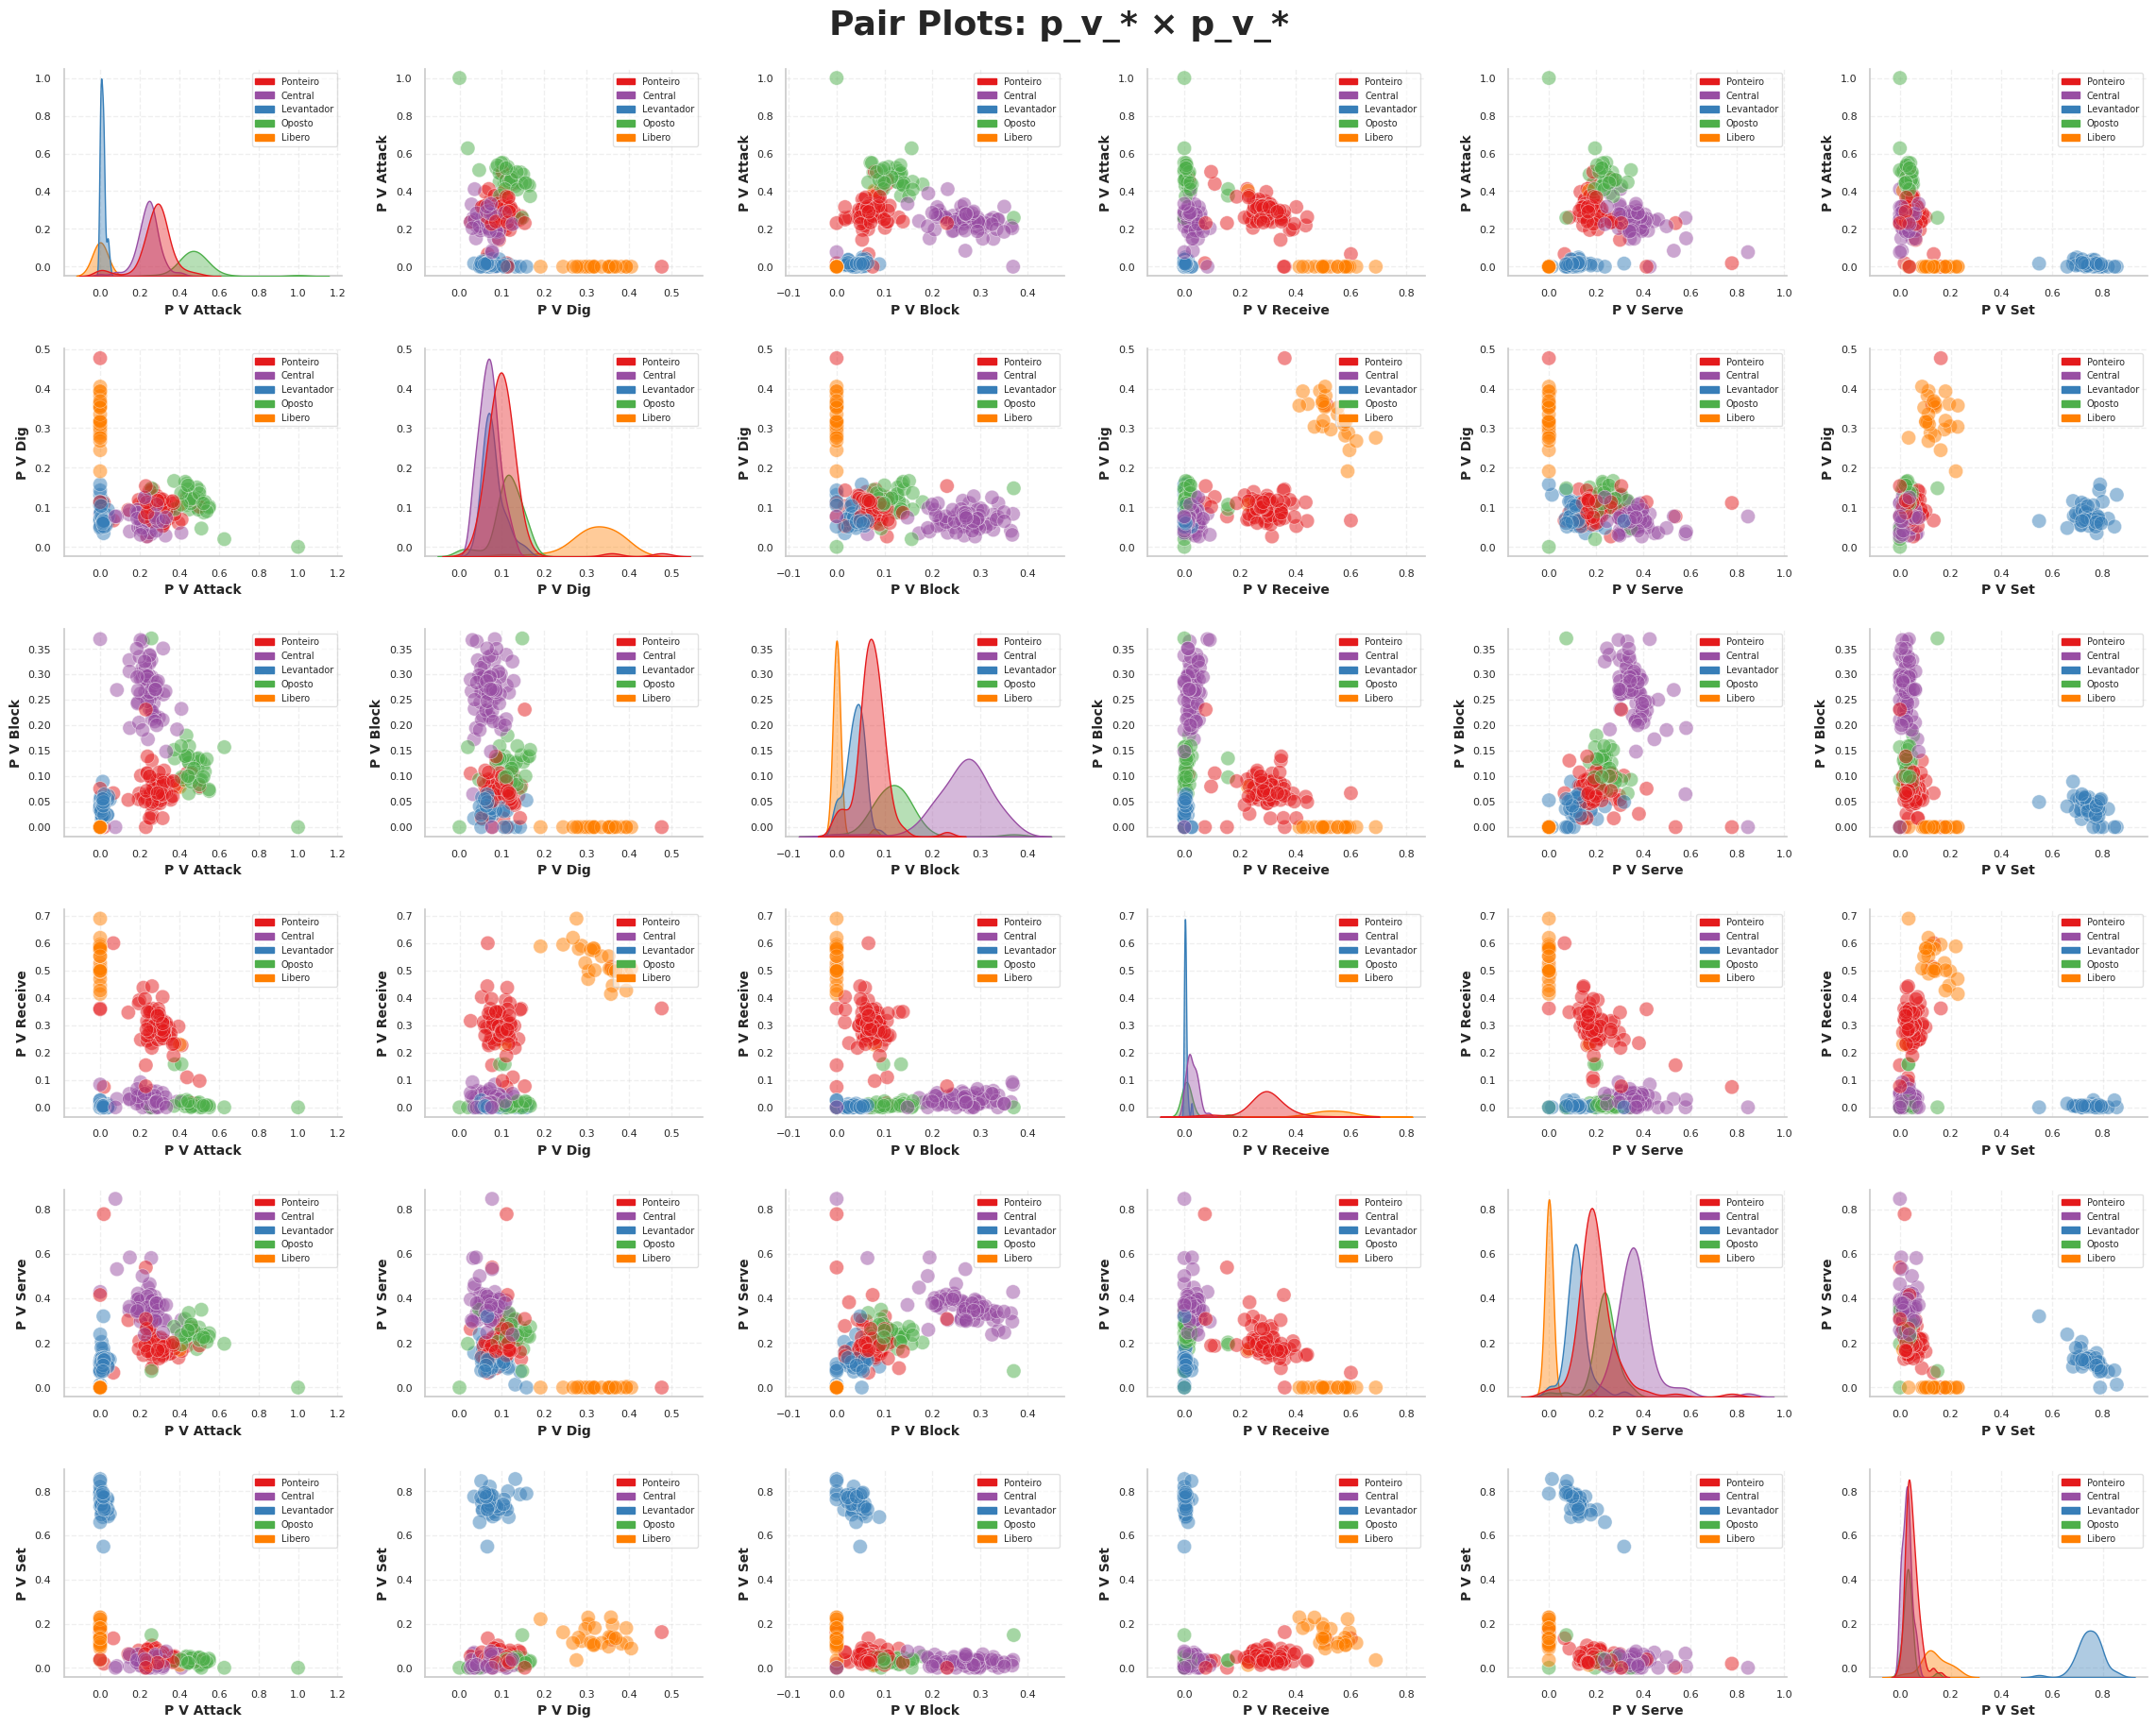

In [ ]:
 # Definindo variáveis de input da função
atributos = [col for col in df_final.columns if col.startswith(('p_v_'))]
pv_attrs = [a for a in atributos if a.startswith('p_v_')]
x_vars, y_vars, titulo = pv_attrs, pv_attrs, 'Pair Plots: p_v_* × p_v_*'

# Chamada a função da matriz de pairplots
build_pairplot(
    x_vars=x_vars,
    y_vars=y_vars,
    titulo=titulo,
    df=df_final,
    posicoes_ordem=ordem,
    cores_posicao=cores_posicao
)

> Os pairplots confirmam, a partir dos dados, a separação entre posições:

> 1. **Levantador (S):** em qualquer par que envolva `p_v_Set`, o Levantador se isola por completo. Seus valores de `p_v_Set` dominam o eixo (acima de 0.6), enquanto todas as demais posições colapsam próximas de zero nessa variável. É a posição com a separação mais limpa de todo o dataset.

> 2. **Líbero (L):** nos pares com `p_v_Receive` e `p_v_Dig`, ocupa uma região própria bem definida, com valores de recepção sistematicamente acima de 0.3 e defesa acima de 0.2. Nos pares com `p_v_Attack` ou `p_v_Block`, colapsa junto à origem, refletindo a proibição dessas ações para a posição.

> 3. **Ponteiro (OH):** os pares de `p_v_Receive` com `p_v_Attack` o posicionam numa região intermediária exclusiva, com participação simultânea em ambos os fundamentos. Essa dupla presença (ataque + recepção) é a assinatura do perfil híbrido que distingue o Ponteiro de todas as outras posições.

> 4. **Central (MB):** `p_v_Block` é o discriminador mais forte. O Central é o único perfil com volume de bloqueio expressivo (acima de 0.15), combinado com `p_v_Serve` elevado. Essa combinação o separa de Ponteiros e Opostos com clareza nos pares `p_v_Block × p_v_Serve` e `p_v_Block × p_v_Attack`.

> 5. **Oposto (O):** é a posição mais difícil de isolar visualmente. Apresenta `p_v_Attack` alto (similar ao Ponteiro), mas `p_v_Receive` próximo de zero (diferente do Ponteiro). O par `p_v_Attack × p_v_Receive` é o que melhor ajuda a separá-lo, porém ainda há sobreposição relevante com Ponteiros e Centrais, sendo assim, um desafio concreto para os algoritmos de clusterização.

## 4.5 Síntese da análise exploratória

A análise exploratória revelou padrões consistentes sobre o comportamento estatístico das cinco posições do voleibol masculino de alto nível, fornecendo direcionamentos claros para as etapas de pré-processamento e seleção de algoritmos de clusterização. Todos os números abaixo referem-se ao conjunto final de **267 atletas**, após o critério de participação mínima.

---

### Critério de participação e escolha das features

Duas decisões da EDA moldam os dados levados à modelagem. Primeiro, seguindo a conclusão do MVP anterior, trabalhamos com o **volume relativo** de cada fundamento (`p_v_*`) e não com métricas de eficiência, que apresentavam alta sobreposição entre posições e não discriminavam os grupos. Segundo, removemos 15 atletas (5,3%) com menos de 10 ações no torneio, cujos perfis `p_v_*` eram estatisticamente instáveis. Ambas as decisões visam garantir que a geometria dos dados reflita as funções táticas, e não ruídos amostrais.

---

### Balanceamento entre as posições

As cinco posições apresentam um desequilíbrio moderado de representatividade: Ponteiros são a maioria, com 86 atletas (32,2%), e Líberos a minoria, com 27 (10,1%), gerando uma proporção de 3,2× entre elas. Esse comportamento é estrutural e natural do voleibol, reflexo de uma escalação padrão que exige dois Ponteiros e dois Centrais em quadra contra apenas um Líbero por jogo. Vale notar que o critério de participação acentuou levemente esse desequilíbrio (a proporção era 2,7× antes do filtro), já que os Líberos concentravam a maior parte dos perfis de baixa participação removidos. Esse desbalanceamento tem impacto direto na clusterização: o K-Means tende a formar clusters de tamanho similar, o que pode prejudicar a recuperação de posições minoritárias como o Líbero; o DBSCAN, por sua vez, pode interpretar posições numerosas e difusas (como Ponteiro) como regiões de baixa densidade. Ambos os efeitos são monitorados nas seções 8 e 9.

---

### Forma das distribuições por posição

A matriz de histogramas mostra que, **dentro de cada posição, cada fundamento é essencialmente unimodal**: um único pico bem definido, com médias e medianas próximas na maioria dos casos. Isso é um bom presságio para a clusterização, pois indica grupos internamente coesos, e não posições subdivididas em subperfis. Onde média e mediana divergem, a causa é uma cauda curta de titulares de elite (por exemplo, `p_v_Set` do Levantador se concentra fortemente em torno de 0,75, com poucos valores abaixo).

Alguns fundamentos exibem uma concentração acentuada de massa em zero para as posições que, por regra ou função, não os executam (é o caso de `p_v_Attack`, `p_v_Block` e `p_v_Serve` para o Líbero, e de `p_v_Receive` para Oposto e Levantador). Esses zeros estruturais são discutidos a seguir.

---

### Valores ausentes e zeros estruturais

O conjunto final (`df_final`) não apresenta valores ausentes: nenhuma das seis variáveis `p_v_*` retém nulos. No entanto, há forte presença de zeros nos dados decorremte das regras e da dinâmica tática do voleibol:

- **Líberos:** `p_v_Attack` (96%), `p_v_Block` (96%) e `p_v_Serve` (89%) zerados na maioria dos registros, refletindo a proibição regulamentar dessas ações.
- **Levantadores:** `p_v_Receive` zerado em 31% dos casos, já que o sistema tático os libera dessa função para ficarem disponíveis ao levantamento.
- **Opostos:** `p_v_Receive` zerado em 19% dos registros, priorizando a especialização ofensiva em detrimento da recepção.

Esses zeros são puramente intrínsecos à função de cada jogador e não resíduos de baixa participação. Esses zeros são altamente informativos para a clusterização: um atleta com `p_v_Attack ≈ 0` e `p_v_Block ≈ 0` carrega uma assinatura geométrica forte que o aproxima naturalmente de outros Líberos no espaço de features.

---

### Distribuição das variáveis e implicações para escala

Todas as seis features (`p_v_*`) são proporções no intervalo **[0, 1]**, o que elimina disparidades de escala intrínsecas. Ainda assim, a aplicação de `StandardScaler` justifica-se para os três algoritmos (K-Means, DBSCAN e HCA com linkage `ward`), todos baseados em distância euclidiana, por dois motivos:

1. **Concentração assimétrica de variância:** `p_v_Set` é quase nula para quatro das cinco posições (Ponteiro, Central, Oposto e Líbero têm média ≤ 0,05) e alta apenas para o Levantador (média 0,747). Vista sobre todos os atletas, a variável assume a forma de duas massas separadas — uma junto de zero e outra isolada em torno de 0,75. Essa amplitude concentrada num único grupo poderia dominar o cálculo de distância mesmo dentro de [0,1], fazendo `p_v_Set` sozinha determinar a formação dos clusters.
2. **Centramento:** o `StandardScaler` garante que nenhuma feature domine as distâncias por ter maior variância absoluta, permitindo que as seis variáveis contribuam proporcionalmente no agrupamento.

---

### Padrões identificados e estratégia de modelagem

As médias e medianas por posição confirmam separações bem delineadas pelas regras do esporte. Cada fundamento tem uma posição que o "lidera", com destaque variável sobre a segunda colocada:

| Fundamento | Posição dominante (média) | 2ª colocada | Destaque |
|:---|:---|:---|:---:|
| `p_v_Set` | Levantador (0,747) | Líbero (0,136) | 5,5× |
| `p_v_Dig` | Líbero (0,317) | Oposto (0,114) | 2,8× |
| `p_v_Block` | Central (0,264) | Oposto (0,121) | 2,2× |
| `p_v_Receive` | Líbero (0,522) | Ponteiro (0,293) | 1,8× |
| `p_v_Attack` | Oposto (0,483) | Ponteiro (0,279) | 1,7× |
| `p_v_Serve` | Central (0,370) | Oposto (0,233) | 1,6× |

Duas assinaturas são quase perfeitamente isoláveis: o **Levantador** (pelo `p_v_Set`, com destaque de 5,5× sobre qualquer outra posição) e o **Líbero** (pela combinação de `p_v_Receive` alto com `p_v_Attack` e `p_v_Block` nulos). São as posições que os algoritmos devem recuperar com maior pureza.

O desafio central estará no **trio ofensivo** — Ponteiro, Oposto e Central —, que compartilha o volume de ataque e é onde os discriminadores se sobrepõem. Os três se separam da seguinte forma:

- **Oposto:** maior `p_v_Attack` (0,483) e `p_v_Receive` praticamente nulo (0,016).
- **Ponteiro:** ataque moderado (0,279) combinado a `p_v_Receive` alto (0,293) — o perfil híbrido ataque/recepção.
- **Central:** distingue-se dos dois pelo `p_v_Block` (0,264, cerca do dobro do Oposto), apesar de menor volume de ataque.

Note que `p_v_Serve`, embora tenha o Central como líder, é o discriminador mais fraco (destaque de apenas 1,6×), com Oposto e Ponteiro em faixas próximas — portanto pouco útil para separar as posições ofensivas. A separação real do trio depende da combinação `Attack × Receive × Block`, não do saque.

Em resumo, a EDA sugere grupos compactos e majoritariamente bem separados, favoráveis à clusterização, com uma zona de sobreposição prevista entre as três posições ofensivas. Esse é o principal obstáculo antecipado para os algoritmos, e será acompanhado de perto nas seções 7 a 9, motivando o uso de K-Means, DBSCAN e HCA.

# 5. Preparação dos dados para a clusterização

Diferente de problemas supervisionados, a clusterização não exige divisão treino/teste: como não há rótulo guiando o aprendizado, não existe risco de vazamento de informação entre conjuntos. O objetivo aqui é avaliar a estrutura intrínseca de todo o conjunto de dados disponível, por isso o X definido abaixo utiliza as 267 instâncias de df_final.

A coluna `Position` (`y`) é mantida separadamente, **fora de `X`**, e só será usada depois de os clusters serem formados, exclusivamente para calcular o ARI e auxiliar a interpretação visual dos resultados.

In [ ]:
# Defineção das features
features = [col for col in df_final.columns if col.startswith('p_v_')]
X = df_final[features].copy()
y = df_final['Position'].copy()

print(f"Instâncias: {len(X)}")
print(f"Features:   {features}")

Instâncias: 267
Features:   ['p_v_Attack', 'p_v_Dig', 'p_v_Block', 'p_v_Receive', 'p_v_Serve', 'p_v_Set']


# 6. Pré-processamento

## 6.1 Padronização das features (StandardScaler)

As features `p_v_*` estão no intervalo $[0, 1]$, mas possuem variâncias muito distintas. Por exemplo, `p_v_Set` ($\sigma \approx 0{,}27$, concentrada quase toda no grupo dos Levantadores) dominaria as métricas de distância se não fosse padronizada. O `StandardScaler` corrige essa distorção, centrando cada variável em média zero e desvio padrão unitário, garantindo que todas contribuam proporcionalmente no cálculo das distâncias.

In [ ]:
scaler = StandardScaler()
X_scaled_all = scaler.fit_transform(X)

print(f"Parâmetros do StandardScaler (ajustado sobre as {len(X)} instâncias):")
print(f"{'Feature':<18} {'Média':>10} {'Desvio Padrão':>15}")
print("─" * 45)
for feat, mean, std in zip(features, scaler.mean_, scaler.scale_):
    print(f"{feat:<18} {mean:>10.4f} {std:>15.4f}")

Parâmetros do StandardScaler (ajustado sobre as 267 instâncias):
Feature                 Média   Desvio Padrão
─────────────────────────────────────────────
p_v_Attack             0.2253          0.1669
p_v_Dig                0.1136          0.0819
p_v_Block              0.1180          0.1035
p_v_Receive            0.1579          0.1839
p_v_Serve              0.2184          0.1357
p_v_Set                0.1669          0.2651


# 7. K-Means

O K-Means itera entre duas etapas até convergência: (1) atribuir cada ponto ao centroide mais próximo e (2) recalcular cada centroide como a média dos pontos do seu cluster. O resultado são `k` grupos esféricos centrados em torno de médias.

O algoritmo foi escolhido por permitir fixar `k=5` diretamente, testando a Hipótese 1 de forma objetiva. A EDA (seção 4.5) identificou grupos compactos e com discriminadores fortes por posição, que é o tipo de estrutura que o K-Means consegue capturar bem.

Ao longo desta seção, vamos desde a execução com `k=5` até a análise de sensibilidade ao número de clusters, verificando não só o desempenho do modelo no nosso dataset, mas também onde ele acerta, onde erra e o que isso revela sobre a estrutura tática dos dados.

## 7.1 Baseline (k=5, configuração padrão)

In [ ]:
# K-Means com k=5 fixo, sem validação prévia da estrutura
km_base = KMeans(n_clusters=5, random_state=SEED, n_init=20)
labels_km_base = km_base.fit_predict(X_scaled_all)

ari_km_base = adjusted_rand_score(y, labels_km_base)
sil_km_base = silhouette_score(X_scaled_all, labels_km_base)

print(f"K-Means (k=5) — avaliação contra as posições reais:")
print(f"  ARI (Adjusted Rand Index) : {ari_km_base:.4f}")
print(f"  Silhouette Score          : {sil_km_base:.4f}")

# Centroides
centroides_base = pd.DataFrame(
    scaler.inverse_transform(km_base.cluster_centers_),
    columns=features
).round(3)

df_km_base = X.copy()
df_km_base['cluster'] = labels_km_base
df_km_base['posicao_real'] = y.values
mapa_cluster_base = df_km_base.groupby('cluster')['posicao_real'].agg(lambda s: s.value_counts().index[0])
centroides_base.index = [f"Cluster {i} (≈{mapa_cluster_base[i]})" for i in centroides_base.index]

print("\nCentroides K-Means (valores originais p_v_*):")
display(centroides_base.style.background_gradient(cmap='RdYlGn', axis=1).format('{:.3f}'))


K-Means (k=5) — avaliação contra as posições reais:
  ARI (Adjusted Rand Index) : 0.9046
  Silhouette Score          : 0.6155

Centroides K-Means (valores originais p_v_*):


,p_v_Attack,p_v_Dig,p_v_Block,p_v_Receive,p_v_Serve,p_v_Set
Cluster 0 (≈Levantador),0.013,0.079,0.038,0.004,0.119,0.747
Cluster 1 (≈Oposto),0.485,0.113,0.115,0.021,0.236,0.030
Cluster 2 (≈Libero),0.000,0.332,-0.000,0.527,0.000,0.141
Cluster 3 (≈Ponteiro),0.285,0.095,0.072,0.303,0.200,0.046
Cluster 4 (≈Central),0.235,0.072,0.263,0.029,0.372,0.028


### Análise do baseline (k=5)

Com `k=5` fixo, o K-Means atinge **ARI = 0.9046** e **Silhouette = 0.6155**, superando com folga a meta da Hipótese 1 (ARI > 0,70). Os cinco clusters correspondem, cada um, a uma posição tática real:

- **Cluster 0 ≈ Levantador (n=45):** isolamento perfeito, com `p_v_Set = 0.747` dominando o perfil e todas as demais ações baixas. É a posição recuperada com maior pureza, como previsto na EDA. Todos os 45 levantadores caem neste cluster, sem intrusos.
- **Cluster 2 ≈ Líbero (n=28):** bem definido, com `p_v_Receive = 0.527` e `p_v_Dig = 0.332`, e ataque/bloqueio praticamente zerados (`p_v_Attack ≈ 0`, `p_v_Block ≈ 0`), refletindo a proibição regulamentar dessas ações. Recupera 26 dos 27 líberos.
- **Cluster 3 ≈ Ponteiro (n=80):** perfil híbrido esperado, com `p_v_Attack = 0.285` combinado a `p_v_Receive = 0.303`, a assinatura ataque/recepção do Ponteiro. Reúne 79 Ponteiros reais.
- **Cluster 1 ≈ Oposto (n=40):** marcado por `p_v_Attack = 0.485` (o mais alto de todos) e `p_v_Receive = 0.021` quase nulo, exatamente o que o distingue do Ponteiro. Isola 36 dos 37 opostos num cluster próprio.
- **Cluster 4 ≈ Central (n=74):** com `p_v_Block = 0.263` (o dobro do Oposto) e `p_v_Serve = 0.372`, reúne os 71 centrais reais num único grupo coeso.

**O diagnóstico central do baseline:** o K-Means com `k=5` reproduz fielmente as cinco posições oficiais. Cada cluster mapeia para uma posição, com destaque para o Levantador e o Líbero, recuperados de forma quase pura, e para a separação bem-sucedida entre Oposto e Ponteiro, apesar do ataque compartilhado. Os poucos erros restantes concentram-se na fronteira ofensiva entre Ponteiro, Oposto e Central. O ARI de 0.9046 confirma numericamente essa correspondência quase perfeita.

## 7.2 Método do Cotovelo e Silhouette Score

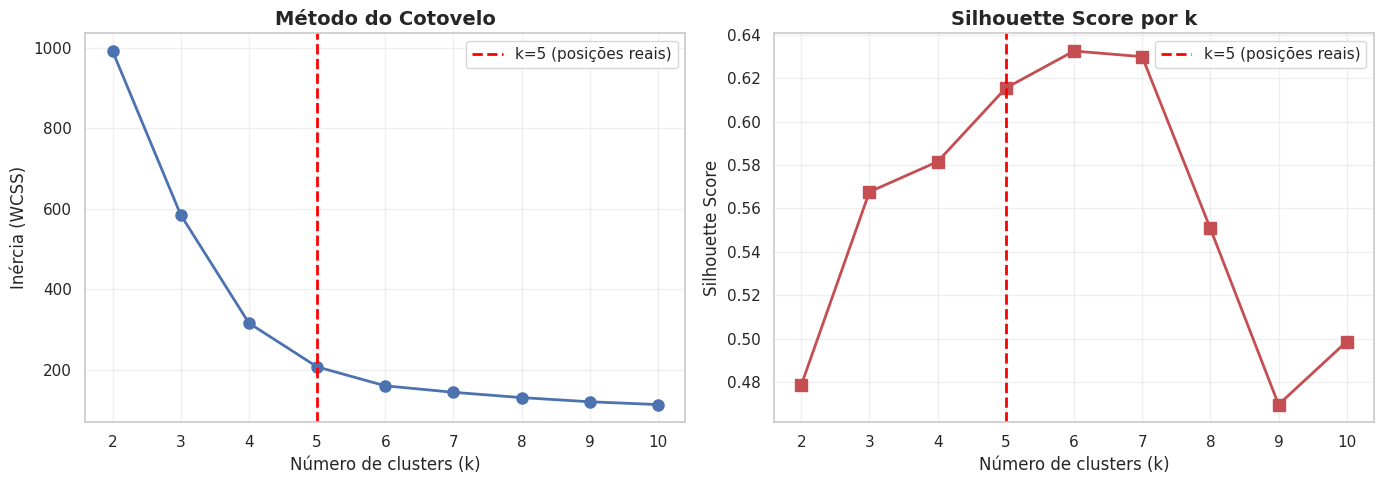

Silhouette com k=5: 0.6155


In [ ]:
# Plot do método cotovelo e silhouette score
inertias, sil_scores = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labs = km.fit_predict(X_scaled_all)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled_all, labs))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', lw=2, ms=8)
axes[0].axvline(x=5, color='red', ls='--', lw=2, label='k=5 (posições reais)')
axes[0].set_xlabel('Número de clusters (k)', fontsize=12)
axes[0].set_ylabel('Inércia (WCSS)', fontsize=12)
axes[0].set_title('Método do Cotovelo', fontsize=14, fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(k_range, sil_scores, 'rs-', lw=2, ms=8)
axes[1].axvline(x=5, color='red', ls='--', lw=2, label='k=5 (posições reais)')
axes[1].set_xlabel('Número de clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score por k', fontsize=14, fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Silhouette com k=5: {sil_scores[3]:.4f}")

### Análise do plot

* **Método do Cotovelo:** a inércia cai de forma acentuada até `k=5` (reduções de 41%, 46% e 34% nas transições sucessivas) e desacelera bruscamente a partir de `k=6`, quando cada cluster adicional passa a reduzir a variância interna em apenas cerca de 10% ou menos. Esse "joelho" na curva, entre `k=5` e `k=6`, indica que cinco a seis grupos capturam a maior parte da estrutura dos dados, e que clusters além disso trazem ganho marginal decrescente, coerente com as cinco posições táticas do voleibol.

* **Silhouette Score:** o Silhouette cresce de forma consistente até atingir o pico em `k=6` (≈0.633), com `k=5` (≈0.616) e `k=7` (≈0.630) logo atrás e praticamente empatados, formando um platô entre cinco e sete grupos. A partir de `k=8` o valor cai de forma abrupta (0.551 em k=8, 0.470 em k=9), sinalizando que dividir os dados em mais de sete grupos degrada a coesão dos clusters. Do ponto de vista puramente geométrico, portanto, a organização ótima dos dados está na faixa de cinco a sete grupos, próxima das cinco posições reais.

Ambas as métricas convergem para a mesma região (`k=5` a `k=6`). Na próxima subseção, avaliamos o K-Means para `k` de 3 a 10 usando o ARI contra as posições reais, para identificar em qual granularidade o algoritmo melhor recupera a estrutura tática conhecida.

## 7.3 Sensibilidade a k (k=3..10)

In [ ]:
# Variando o k do K-Means
resultados_km_k = {}

for k in range(3, 10):
    km_k = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labs_k = km_k.fit_predict(X_scaled_all)
    ari_k = adjusted_rand_score(y, labs_k)
    sil_k = silhouette_score(X_scaled_all, labs_k)
    resultados_km_k[k] = {'ARI': ari_k, 'Silhouette': sil_k, 'labels': labs_k, 'modelo': km_k}
    print(f"k={k}:  ARI={ari_k:.4f}  |  Silhouette={sil_k:.4f}")

melhor_k_ari = max(resultados_km_k, key=lambda k: resultados_km_k[k]['ARI'])
print(f"\nMelhor k por ARI: {melhor_k_ari}  (ARI={resultados_km_k[melhor_k_ari]['ARI']:.4f})")

# Centroides e distribuição do melhor k
km_best = resultados_km_k[melhor_k_ari]['modelo']
labels_km_best = resultados_km_k[melhor_k_ari]['labels']

centroides_best = pd.DataFrame(
    scaler.inverse_transform(km_best.cluster_centers_),
    columns=features
).round(3)

df_km_best = X.copy()
df_km_best['cluster'] = labels_km_best
df_km_best['posicao_real'] = y.values
mapa_cluster_best = df_km_best.groupby('cluster')['posicao_real'].agg(lambda s: s.value_counts().index[0])
contagem_clusters = pd.Series(labels_km_best).value_counts().sort_index()
centroides_best.index = [f"Cluster {i} (≈{mapa_cluster_best[i]}, n={contagem_clusters[i]})" for i in centroides_best.index]

print(f"\nK-Means (k={melhor_k_ari}) — avaliação contra as posições reais:")
print(f"  ARI (Adjusted Rand Index) : {resultados_km_k[melhor_k_ari]['ARI']:.4f}")
print(f"  Silhouette Score          : {resultados_km_k[melhor_k_ari]['Silhouette']:.4f}")

print(f"\nCentroides K-Means (valores originais p_v_*):")
display(centroides_best.style.background_gradient(cmap='RdYlGn', axis=1).format('{:.3f}'))

k=3:  ARI=0.3522  |  Silhouette=0.5676
k=4:  ARI=0.7373  |  Silhouette=0.5816
k=5:  ARI=0.9046  |  Silhouette=0.6155
k=6:  ARI=0.8861  |  Silhouette=0.6326
k=7:  ARI=0.8834  |  Silhouette=0.6300
k=8:  ARI=0.7824  |  Silhouette=0.5508
k=9:  ARI=0.6517  |  Silhouette=0.4695
k=10:  ARI=0.7180  |  Silhouette=0.4986

Melhor k por ARI: 5  (ARI=0.9046)

K-Means (k=5) — avaliação contra as posições reais:
  ARI (Adjusted Rand Index) : 0.9046
  Silhouette Score          : 0.6155

Centroides K-Means (valores originais p_v_*):


,p_v_Attack,p_v_Dig,p_v_Block,p_v_Receive,p_v_Serve,p_v_Set
"Cluster 0 (≈Levantador, n=45)",0.013,0.079,0.038,0.004,0.119,0.747
"Cluster 1 (≈Oposto, n=40)",0.485,0.113,0.115,0.021,0.236,0.030
"Cluster 2 (≈Libero, n=28)",0.000,0.332,-0.000,0.527,0.000,0.141
"Cluster 3 (≈Ponteiro, n=80)",0.285,0.095,0.072,0.303,0.200,0.046
"Cluster 4 (≈Central, n=74)",0.235,0.072,0.263,0.029,0.372,0.028


### Análise da sensibilidade

Os ganhos de ARI não são graduais, eles se concentram na subida até `k=5` e se esgotam a partir daí:

| Transição | Δ ARI | O que acontece |
|---|---|---|
| k=3 → k=4 | +0.385 | Maior salto: posições gravemente fundidas começam a se separar |
| k=4 → k=5 | +0.167 | Segundo maior salto: a última posição ofensiva ganha cluster próprio |
| k=5 → k=6 | −0.018 | Ganho negativo: dividir mais afasta dos rótulos reais |
| k=6 → k=7 | −0.003 | Estável, sem ganho |
| k=7 → k=8 | −0.101 | Queda: fragmentação começa a prejudicar |
| k=8 → k=9 | −0.131 | Queda acentuada |
| k=9 → k=10 | +0.066 | Recuperação parcial, ainda muito abaixo de k=5 |

O padrão é inequívoco: o ARI cresce até `k=5` e decresce a partir de `k=6`. O salto de `k=4 → k=5` (+0.167) é o que completa a recuperação das cinco posições, adicionando o cluster que faltava para separar as funções ofensivas. Já a transição `k=5 → k=6` é levemente negativa (−0.018): forçar um sexto cluster não revela nenhuma subdivisão tática real, apenas quebra um grupo coeso e afasta a partição dos rótulos verdadeiros.

**O melhor ARI ocorre exatamente em `k=5` (0.9046)**, coincidindo com o número de posições táticas do voleibol. O Silhouette, por sua vez, tem seu pico em `k=6` (0.6326), com `k=5` logo atrás (0.6155). Essa pequena discordância é esperada: a silhueta mede coesão puramente geométrica e é levemente maximizada ao subdividir um grupo, enquanto o ARI mede concordância com as posições reais. O fato de as duas métricas apontarem para a mesma vizinhança (`k=5`–`k=6`), e de o ARI cravar `k=5`, confirma que a estrutura geométrica dos dados corresponde às cinco posições oficiais.

Os centroides de `k=5` (tabela acima) detalham essa correspondência: cada um dos cinco clusters é dominado pela assinatura de uma posição, o Levantador pelo `p_v_Set` (0.747), o Líbero pelo `p_v_Receive` (0.527), o Central pelo `p_v_Block` (0.263), o Oposto pelo `p_v_Attack` alto (0.485) com recepção nula, e o Ponteiro pelo equilíbrio entre ataque (0.285) e recepção (0.303). Não há clusters redundantes nem posições ausentes.

# 8. DBSCAN

O DBSCAN identifica clusters como regiões de alta densidade separadas por regiões esparsas. Diferente do K-Means, não exige definir o número de clusters a priori e marca pontos em regiões de baixa densidade como **ruído** (label `−1`). Os dois hiperparâmetros principais são `eps` (raio da vizinhança) e `min_samples` (mínimo de pontos para formar um core point).

O algoritmo foi escolhido para testar a Hipótese 2: como as densidades variam entre posições (Ponteiro é numeroso e difuso, Líbero é compacto e minoritário), é plausível que o DBSCAN tenha dificuldade em isolar exatamente 5 clusters sem ruído. Além disso, por não assumir formato esférico, ele pode revelar estruturas que o K-Means não captura.

Ao longo desta seção, executamos o DBSCAN com os hiperparâmetros padrão do scikit-learn e, em seguida, realizamos uma busca em grade sobre `eps` e `min_samples` para avaliar a sensibilidade do algoritmo a essas escolhas.

## 8.1 Baseline (eps=0.5, min_samples=5)

In [ ]:
# Baseline DBSCAN com ep 0.5 e 5 min_samplses
db_base = DBSCAN(eps=0.5, min_samples=5)
labels_db_base = db_base.fit_predict(X_scaled_all)

n_clust_base = len(set(labels_db_base)) - (1 if -1 in labels_db_base else 0)
n_ruido_base = (labels_db_base == -1).sum()
ari_db_base  = adjusted_rand_score(y, labels_db_base)
sil_db_base  = silhouette_score(X_scaled_all, labels_db_base) if n_clust_base > 1 else 0.0

print(f"DBSCAN (default: eps=0.5, min_samples=5):")
print(f"  Clusters encontrados : {n_clust_base}")
print(f"  Ruído (atletas)      : {n_ruido_base} de {len(X)} ({n_ruido_base/len(X)*100:.1f}%)")
print(f"  ARI                  : {ari_db_base:.4f}")
print(f"  Silhouette           : {sil_db_base:.4f}")

DBSCAN (default: eps=0.5, min_samples=5):
  Clusters encontrados : 5
  Ruído (atletas)      : 47 de 267 (17.6%)
  ARI                  : 0.6661
  Silhouette           : 0.4924


### Análise dos resultados

Os hiperparâmetros padrão do scikit-learn (`eps=0.5`, `min_samples=5`) encontram exatamente 5 clusters, mas o ARI de 0.6661 fica abaixo da meta de 0,70. O Silhouette de 0.4924 também é inferior ao obtido pelo K-Means com `k=5` (0.6155), indicando clusters menos coesos e pior separados.

Além disso, 47 dos 267 atletas (17,6%) foram classificados como ruído, um custo que o K-Means não tem, já que classifica 100% dos pontos. Isso significa que quase 1 em cada 6 atletas ficou sem agrupamento algum.

Mesmo no cenário em que o DBSCAN "acerta" o número de clusters, ele apresenta os dois sintomas previstos pela Hipótese 2: ARI inferior ao K-Means e descarte de uma fração significativa dos dados como ruído.

## 8.2 Busca de hiperparâmetros (eps × min_samples)

In [ ]:
# Variando hiperparâmetros para DBSCAN
eps_vals = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
ms_vals  = [3, 5]

resultados_dbscan = []

print(f"{'eps':>5}  {'min_s':>5}  {'n_clust':>8}  {'n_ruido':>8}  {'ARI':>8}  {'Silhouette':>11}")
print('─' * 55)

for eps in eps_vals:
    for ms in ms_vals:
        db = DBSCAN(eps=eps, min_samples=ms)
        labs = db.fit_predict(X_scaled_all)
        n_clust  = len(set(labs)) - (1 if -1 in labs else 0)
        n_ruido  = (labs == -1).sum()
        ari  = adjusted_rand_score(y, labs)
        sil  = silhouette_score(X_scaled_all, labs) if n_clust > 1 else 0.0
        resultados_dbscan.append({'eps': eps, 'min_samples': ms,
                                  'n_clusters': n_clust, 'n_ruido': n_ruido,
                                  'ARI': ari, 'Silhouette': sil, 'labels': labs})
        print(f"  {eps:>5.1f}  {ms:>5}  {n_clust:>8}  {n_ruido:>8}  {ari:>8.4f}  {sil:>11.4f}")

# Melhore resultado para DBSCAN
melhor_db = max(resultados_dbscan, key=lambda x: x['ARI'])
labels_db = melhor_db['labels']
ari_db    = melhor_db['ARI']
sil_db    = melhor_db['Silhouette']
print(f"\nMelhor DBSCAN: eps={melhor_db['eps']}, min_samples={melhor_db['min_samples']}")
print(f"  Clusters encontrados: {melhor_db['n_clusters']}  |  Ruído: {melhor_db['n_ruido']} atletas")
print(f"  ARI={ari_db:.4f}  |  Silhouette={sil_db:.4f}")

print(f"\nCentroides K-Means (valores originais p_v_*):")
display(centroides_best.style.background_gradient(cmap='RdYlGn', axis=1).format('{:.3f}'))

  eps  min_s   n_clust   n_ruido       ARI   Silhouette
───────────────────────────────────────────────────────
    0.3      3         8       120    0.2558       0.0456
    0.3      5         7       145    0.1861      -0.0358
    0.5      3         5        42    0.6966       0.5110
    0.5      5         5        47    0.6661       0.4924
    0.7      3         4        19    0.6741       0.5604
    0.7      5         4        21    0.6634       0.5525
    1.0      3         3        12    0.3520       0.5348
    1.0      5         3        12    0.3520       0.5348
    1.5      3         3         4    0.3527       0.5708
    1.5      5         3         4    0.3527       0.5708
    2.0      3         2         3    0.2106       0.4321
    2.0      5         2         3    0.2106       0.4321

Melhor DBSCAN: eps=0.5, min_samples=3
  Clusters encontrados: 5  |  Ruído: 42 atletas
  ARI=0.6966  |  Silhouette=0.5110


### Análise da busca

A busca não altera o quadro do baseline: a melhor configuração (`eps=0.5`, `min_samples=3`) é praticamente a mesma, com 5 clusters, ARI de 0.6966 e 42 atletas descartados como ruído. Reduzir `min_samples` de 5 para 3 traz um ganho marginal de ARI (0.6661 → 0.6966), mas mantém o algoritmo abaixo da meta de 0,70 e com 16% dos atletas sem classificação. Esse ganho vem apenas de resgatar do ruído 5 atletas de fronteira, que com o critério de densidade mais frouxo passam a ser absorvidos pelo cluster correto de sua posição.

A grade revela um trade-off claro entre os extremos de `eps`:
- **`eps` pequeno (0.3):** fragmentação severa, com 120 a 145 atletas em ruído (até 54% do dataset) e ARI abaixo de 0.26. O raio é pequeno demais para formar vizinhanças densas.
- **`eps` grande (1.0–2.0):** ruído quase zero, mas ARI desaba para 0.21–0.35. O raio funde múltiplas posições reais num único cluster (chegando a apenas 2 a 3 clusters).
- **Faixa útil restrita a `eps` ≈ 0.5–0.7**, onde ARI e ruído moderado coexistem.

Vale observar que Silhouette e ARI divergem com `eps` alto: em `eps=1.5` (ms=3), o Silhouette (0.5708) é maior do que na melhor configuração por ARI (0.5110), mas o ARI é muito pior (0.3527 vs. 0.6966). Isso acontece porque fundir várias posições num cluster grande produz pontos geometricamente "coesos" entre si, mas que na realidade pertencem a classes diferentes.

**Hipótese 2 confirmada.** Embora o DBSCAN consiga recuperar 5 clusters, ele não o faz "sem ruído": mesmo na melhor configuração, 42 atletas (16%) são descartados e o ARI (0.6966) fica abaixo do limiar de 0,70 e bem aquém do K-Means (0.9046). A dificuldade prevista pela Hipótese 2 se confirma, agora localizada não no número de clusters, mas na incapacidade do algoritmo de classificar os atletas de fronteira entre posições, que caem em regiões de densidade insuficiente e são marcados como ruído.

# 9. Clusterização Hierárquica (HCA)

A clusterização hierárquica aglomerativa parte do princípio oposto ao K-Means: em vez de fixar `k` centroides, ela trata cada amostra inicialmente como seu próprio cluster e vai fundindo, a cada passo, o par de clusters mais similar entre si, até restar um único cluster. O resultado é uma árvore (**dendrograma**) que registra a distância de cada fusão, permitindo cortar a hierarquia no número de clusters desejado a qualquer momento, sem precisar re-treinar o modelo.

O algoritmo foi escolhido para testar a Hipótese 3: além de verificar se atinge ARI $> 0,70$ com `k=5`, o dendrograma permite visualizar diretamente a proximidade entre as posições, algo que K-Means e DBSCAN não expõem. A EDA (seção 4.5) sugere que Levantador e Líbero devem se separar do restante em alturas elevadas, enquanto Oposto, Ponteiro e Central devem se fundir em alturas mais baixas. Testamos quatro critérios de linkage (`ward`, `complete`, `average`, `single`), conforme recomendado pelo material de referência da disciplina, já que escolhas diferentes de critério de fusão levam a resultados distintos.

Ao longo desta seção, executamos a HCA com linkage `ward` e `k=5`, analisamos o dendrograma e, em seguida, realizamos uma busca sobre os diferentes critérios de linkage e números de clusters.

## 9.1 Dendrograma e baseline (linkage='ward', k=5)

O dendrograma abaixo mostra todas as fusões sucessivas feitas pela HCA sobre os 267 atletas (rotulados pela posição real apenas para leitura visual, o algoritmo não usa esse rótulo). A linha tracejada marca a altura de corte usada para obter exatamente 5 clusters, a configuração oficial testada pela Hipótese 3.

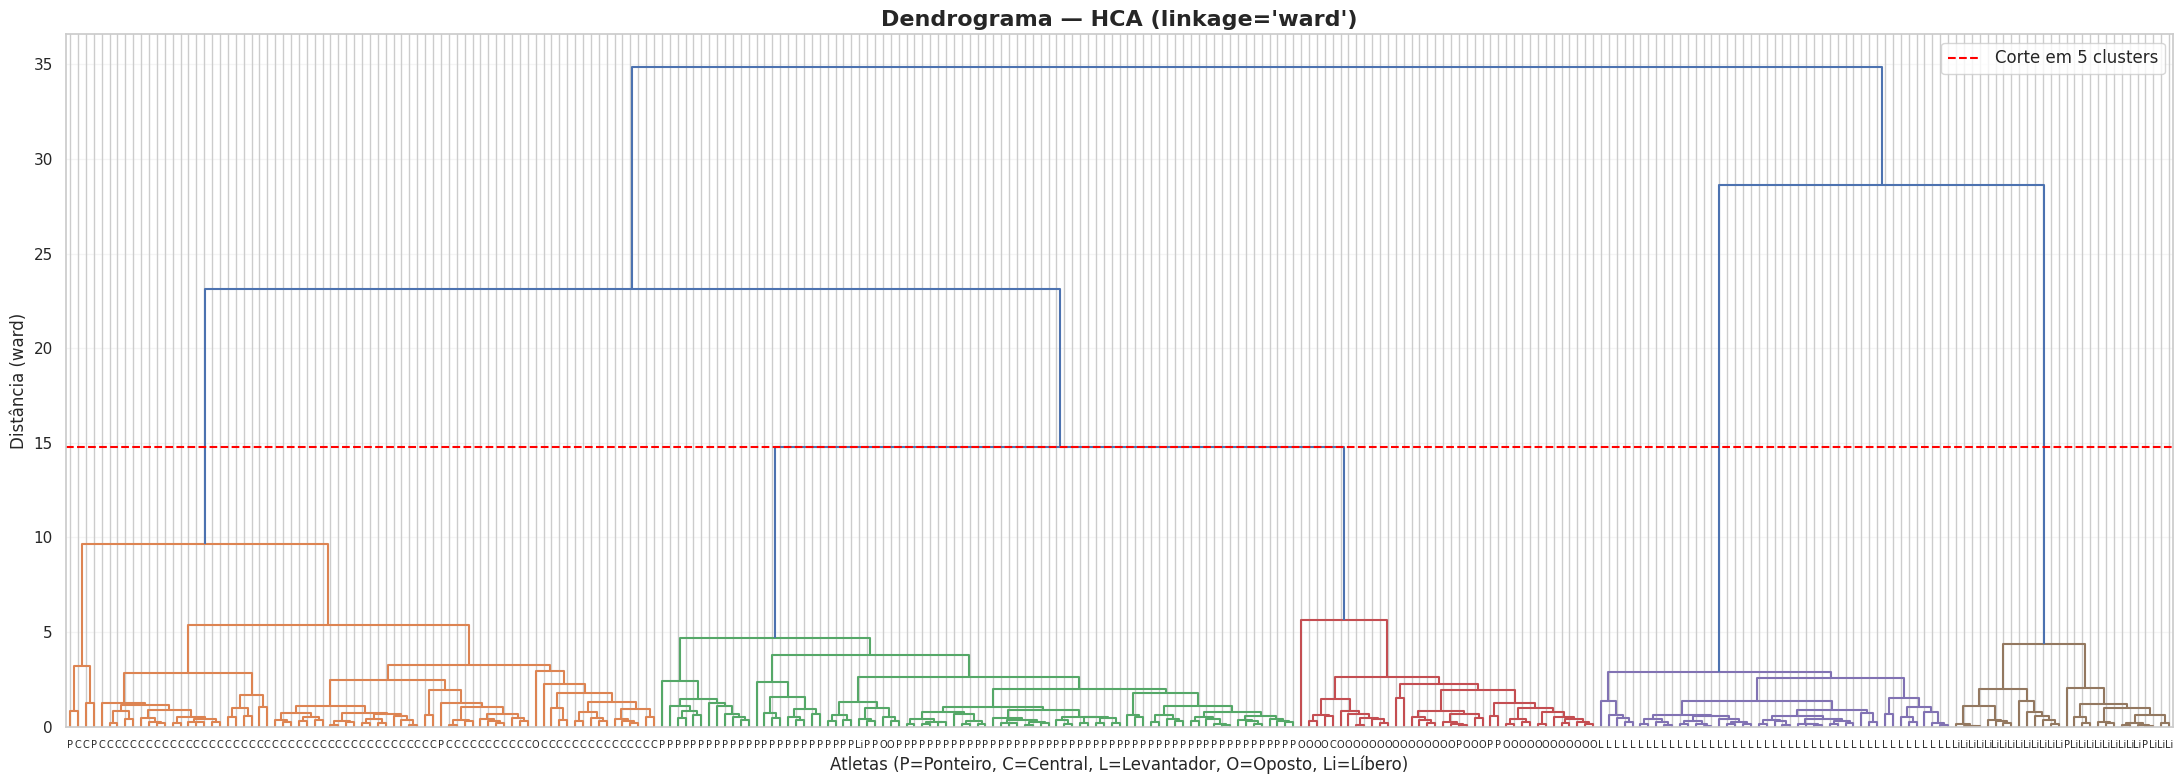

In [ ]:
# Dendograma do HCA com linkage ward e 5 clusters
Z = scipy_linkage(X_scaled_all, method='ward')

siglas = {'Ponteiro': 'P', 'Central': 'C', 'Levantador': 'L', 'Oposto': 'O', 'Libero': 'Li'}
y_siglas = y.map(siglas).values

plt.figure(figsize=(22, 8))
dendrogram(Z, labels=y_siglas, leaf_rotation=0, leaf_font_size=7, color_threshold=Z[-4, 2])
plt.axhline(y=Z[-4, 2], color='red', ls='--', lw=1.5, label='Corte em 5 clusters')
plt.title("Dendrograma — HCA (linkage='ward')", fontsize=16, fontweight='bold')
plt.xlabel('Atletas (P=Ponteiro, C=Central, L=Levantador, O=Oposto, Li=Líbero)', fontsize=12)
plt.ylabel('Distância (ward)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

> **O dendrograma revela a hierarquia de proximidade tática entre as posições.** A fusão final, na maior altura (distância ≈ 35), une dois macro-blocos bem definidos: de um lado, o **trio ofensivo** (Ponteiro, Central e Oposto), que atua na rede e compartilha o volume de ataque; do outro, o **grupo de bastidores** (Levantador e Líbero), cujas funções (armar o jogo e defender) os afastam estatisticamente dos atacantes. Essa separação em altura elevada confirma o que a EDA previa: Levantador e Líbero são as posições mais distintas do conjunto. Descendo na árvore, dentro do bloco ofensivo, o corte em `k=5` separa com sucesso os três subgrupos (Ponteiro, Central e Oposto), cada um em seu próprio ramo, apesar de se fundirem em alturas relativamente baixas por compartilharem perfis semelhantes.

In [ ]:
# HCA com linkage ward
hca_base = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels_hca_base = hca_base.fit_predict(X_scaled_all)

ari_hca_base = adjusted_rand_score(y, labels_hca_base)
sil_hca_base = silhouette_score(X_scaled_all, labels_hca_base)

print(f"HCA (linkage=ward, n_clusters=5) — avaliação contra os rótulos reais:")
print(f"  ARI (Adjusted Rand Index) : {ari_hca_base:.4f}")
print(f"  Silhouette Score          : {sil_hca_base:.4f}")

# Perfis médios por cluster
df_hca_base = X.copy()
df_hca_base['cluster'] = labels_hca_base
df_hca_base['posicao_real'] = y.values
perfis_hca_base = df_hca_base.groupby('cluster')[features].mean().round(3)
mapa_cluster_hca = df_hca_base.groupby('cluster')['posicao_real'].agg(lambda s: s.value_counts().index[0])
perfis_hca_base.index = [f"Cluster {i} (≈{mapa_cluster_hca[i]})" for i in perfis_hca_base.index]

print("\nPerfil médio por cluster (valores originais p_v_*):")
display(perfis_hca_base.style.background_gradient(cmap='RdYlGn', axis=1).format('{:.3f}'))


HCA (linkage=ward, n_clusters=5) — avaliação contra os rótulos reais:
  ARI (Adjusted Rand Index) : 0.8758
  Silhouette Score          : 0.6173

Perfil médio por cluster (valores originais p_v_*):


,p_v_Attack,p_v_Dig,p_v_Block,p_v_Receive,p_v_Serve,p_v_Set
Cluster 0 (≈Central),0.235,0.072,0.259,0.031,0.374,0.028
Cluster 1 (≈Oposto),0.490,0.114,0.115,0.014,0.238,0.030
Cluster 2 (≈Levantador),0.013,0.079,0.038,0.004,0.119,0.747
Cluster 3 (≈Libero),0.000,0.332,0.000,0.527,0.000,0.141
Cluster 4 (≈Ponteiro),0.288,0.096,0.074,0.301,0.195,0.047


### Análise dos resultados

A HCA com linkage `ward` e `k=5` atingiu ARI de 0.8758, superando a meta de 0,70 com folga. O Silhouette Score de 0.6173 é praticamente idêntico ao do K-Means (0.6155) e superior ao do DBSCAN (0.5110), indicando clusters de coesão semelhante entre os dois melhores algoritmos.

Os perfis médios por cluster reproduzem fielmente as cinco posições, com valores muito próximos dos centroides do K-Means:

- **Cluster 2 ≈ Levantador (n=45):** `p_v_Set = 0.747`, isolamento perfeito, sem intrusos.
- **Cluster 3 ≈ Líbero (n=28):** `p_v_Receive = 0.527` e `p_v_Dig = 0.332`, com ataque e bloqueio zerados.
- **Cluster 4 ≈ Ponteiro (n=81):** `p_v_Attack = 0.288` e `p_v_Receive = 0.301`, o perfil híbrido ataque/recepção.
- **Cluster 1 ≈ Oposto (n=38):** `p_v_Attack = 0.490` (o mais alto) e `p_v_Receive ≈ 0`, com cluster próprio, separado do Ponteiro.
- **Cluster 0 ≈ Central (n=75):** `p_v_Block = 0.259` e `p_v_Serve = 0.374`, num único grupo coeso.

Cada uma das cinco posições recebe um cluster dedicado, incluindo o Oposto e o Central, sem fragmentações nem posições ausentes. Os poucos erros (visíveis na tabela de perfis e na comparação com os rótulos reais) concentram-se, como esperado, na fronteira ofensiva entre Ponteiro, Oposto e Central.

**Hipótese 3 confirmada.** A HCA atingiu ARI de 0.8758 com `k=5` (acima do limiar de 0,70) e desempenho comparável ao K-Means, cumprindo o critério quantitativo. Além disso, o dendrograma entregou sua principal promessa: expor visualmente a hierarquia de proximidade tática que K-Means e DBSCAN não revelam, com Levantador e Líbero separando-se do trio ofensivo em alturas elevadas de fusão. Na próxima subseção, testamos os diferentes critérios de linkage e valores de `k` para confirmar a robustez desse resultado.

## 9.2 Busca de hiperparâmetros (linkage e k)

In [ ]:
# Variando linkages para HCA
linkages = ['ward', 'complete', 'average', 'single']
resultados_linkage = {}

for link in linkages:
    hca = AgglomerativeClustering(n_clusters=5, linkage=link)
    labs = hca.fit_predict(X_scaled_all)
    ari = adjusted_rand_score(y, labs)
    sil = silhouette_score(X_scaled_all, labs)
    resultados_linkage[link] = {'ARI': ari, 'Silhouette': sil, 'labels': labs}
    print(f"linkage={link:<10}  ARI={ari:.4f}  |  Silhouette={sil:.4f}")

melhor_linkage = max(resultados_linkage, key=lambda l: resultados_linkage[l]['ARI'])
print(f"\nMelhor linkage por ARI: {melhor_linkage}  (ARI={resultados_linkage[melhor_linkage]['ARI']:.4f})")


linkage=ward        ARI=0.8758  |  Silhouette=0.6173
linkage=complete    ARI=0.5097  |  Silhouette=0.4204
linkage=average     ARI=0.3489  |  Silhouette=0.5449
linkage=single      ARI=0.3549  |  Silhouette=0.5651

Melhor linkage por ARI: ward  (ARI=0.8758)


In [ ]:
# Variando o numero de clusters para HCA
resultados_hca_k = {}

for k in range(2, 11):
    hca_k = AgglomerativeClustering(n_clusters=k, linkage=melhor_linkage)
    labs_k = hca_k.fit_predict(X_scaled_all)
    ari_k = adjusted_rand_score(y, labs_k)
    sil_k = silhouette_score(X_scaled_all, labs_k)
    resultados_hca_k[k] = {'ARI': ari_k, 'Silhouette': sil_k, 'labels': labs_k}
    print(f"k={k}:  ARI={ari_k:.4f}  |  Silhouette={sil_k:.4f}")

melhor_k_hca = max(resultados_hca_k, key=lambda k: resultados_hca_k[k]['ARI'])
print(f"\nMelhor k por ARI: {melhor_k_hca}  (ARI={resultados_hca_k[melhor_k_hca]['ARI']:.4f})")


k=2:  ARI=0.3133  |  Silhouette=0.4793
k=3:  ARI=0.3551  |  Silhouette=0.5679
k=4:  ARI=0.7162  |  Silhouette=0.5812
k=5:  ARI=0.8758  |  Silhouette=0.6173
k=6:  ARI=0.8746  |  Silhouette=0.6350
k=7:  ARI=0.8721  |  Silhouette=0.6315
k=8:  ARI=0.7820  |  Silhouette=0.5557
k=9:  ARI=0.7069  |  Silhouette=0.4957
k=10:  ARI=0.6917  |  Silhouette=0.4637

Melhor k por ARI: 5  (ARI=0.8758)


### Análise da busca

**Linkage:** o `ward` foi o melhor por ampla margem (ARI = 0.8758), seguido por `complete` (0.5097), `single` (0.3549) e `average` (0.3489). Esse resultado era esperado, já que o `ward` minimiza a variância intra-cluster a cada fusão, sendo o critério de linkage mais robusto.

**Sensibilidade a k (linkage=ward):** o padrão segue a mesma lógica do K-Means (seção 7.3):
- O salto de `k=3 → k=4` (+0.361) é o maior, resolvendo fusões graves entre posições.
- O salto de `k=4 → k=5` (+0.160) completa a recuperação das cinco posições, adicionando o cluster que faltava para separar as funções ofensivas.
- De `k=5 → k=6` o ARI cai levemente (−0.001) e segue caindo a partir daí, confirmando que dividir além de cinco grupos não revela estrutura tática nova.

O melhor ARI da HCA ocorre em `k=5` (0.8758), coincidindo com o número de posições táticas. O Silhouette, por sua vez, tem pico em `k=6` (0.6350), com `k=5` logo atrás (0.6173), a mesma pequena divergência entre coesão geométrica e concordância com os rótulos já discutida na seção 7.3. Assim como no K-Means, ambas as métricas convergem para a vizinhança de `k=5`, e é o ARI que crava esse valor como a granularidade que melhor corresponde às posições reais.

Esse resultado consolida a Hipótese 3: a HCA não só ultrapassa o limiar de 0,70 com `k=5`, como o faz na configuração de linkage e granularidade mais naturais, em desempenho comparável ao K-Means (0.8758 contra 0.9046).

# 10. Avaliação final

Com as análises individuais dos três algoritmos concluídas (seções 7, 8 e 9), esta seção reúne os resultados numa comparação direta, respondendo às três hipóteses definidas na seção 1.4.


In [ ]:
# Melhores resultados de cada algoritmo
melhor_k_km = max(resultados_km_k, key=lambda k: resultados_km_k[k]['ARI'])
melhor_k_hca = max(resultados_hca_k, key=lambda k: resultados_hca_k[k]['ARI'])

df_melhor = pd.DataFrame({
    'Algoritmo':   [f'K-Means (k={melhor_k_km})',
                     f"DBSCAN (eps={melhor_db['eps']}, ms={melhor_db['min_samples']})",
                     f'HCA (linkage={melhor_linkage}, k={melhor_k_hca})'],
    'Clusters':    [melhor_k_km, melhor_db['n_clusters'], melhor_k_hca],
    'ARI':         [resultados_km_k[melhor_k_km]['ARI'], ari_db, resultados_hca_k[melhor_k_hca]['ARI']],
    'Silhouette':  [resultados_km_k[melhor_k_km]['Silhouette'], sil_db, resultados_hca_k[melhor_k_hca]['Silhouette']],
})

print('\n Melhor configuração de cada algoritmo (k livre, sem fixar k=5):')
display(df_melhor.style
    .format({'ARI': '{:.4f}', 'Silhouette': '{:.4f}'})
    .highlight_max(subset=['ARI','Silhouette'], color='rgba(46, 204, 113, 0.3)')
)



 Melhor configuração de cada algoritmo (k livre, sem fixar k=5):


,Algoritmo,Clusters,ARI,Silhouette
0,K-Means (k=5),5,0.9046,0.6155
1,"DBSCAN (eps=0.5, ms=3)",5,0.6966,0.5110
2,"HCA (linkage=ward, k=5)",5,0.8758,0.6173


### Análise dos resultados

Os três algoritmos convergem para 5 clusters: K-Means e HCA elegem `k=5` como o de maior ARI e o DBSCAN também encontra 5 grupos. Três lógicas distintas apontando de forma independente para `k=5` confirma que as cinco posições correspondem a grupos reais no espaço de features. K-Means (0.9046) e HCA (0.8758) se destacam como os mais adequados; o DBSCAN (0.6966), apesar de acertar o número de grupos, fica atrás pela fração de atletas que deixa sem classificação.

# 11. Comparação visual: clusters vs posições reais

Reduzimos o espaço de 6 dimensões para 2 com **PCA** (Análise de Componentes Principais) e plotamos a melhor configuração de cada um dos três algoritmos lado a lado com as posições reais. O PCA maximiza a variância explicada nos dois primeiros eixos (juntos, cerca de 76% da variância total), permitindo visualizar a separação entre os grupos num plano 2D.

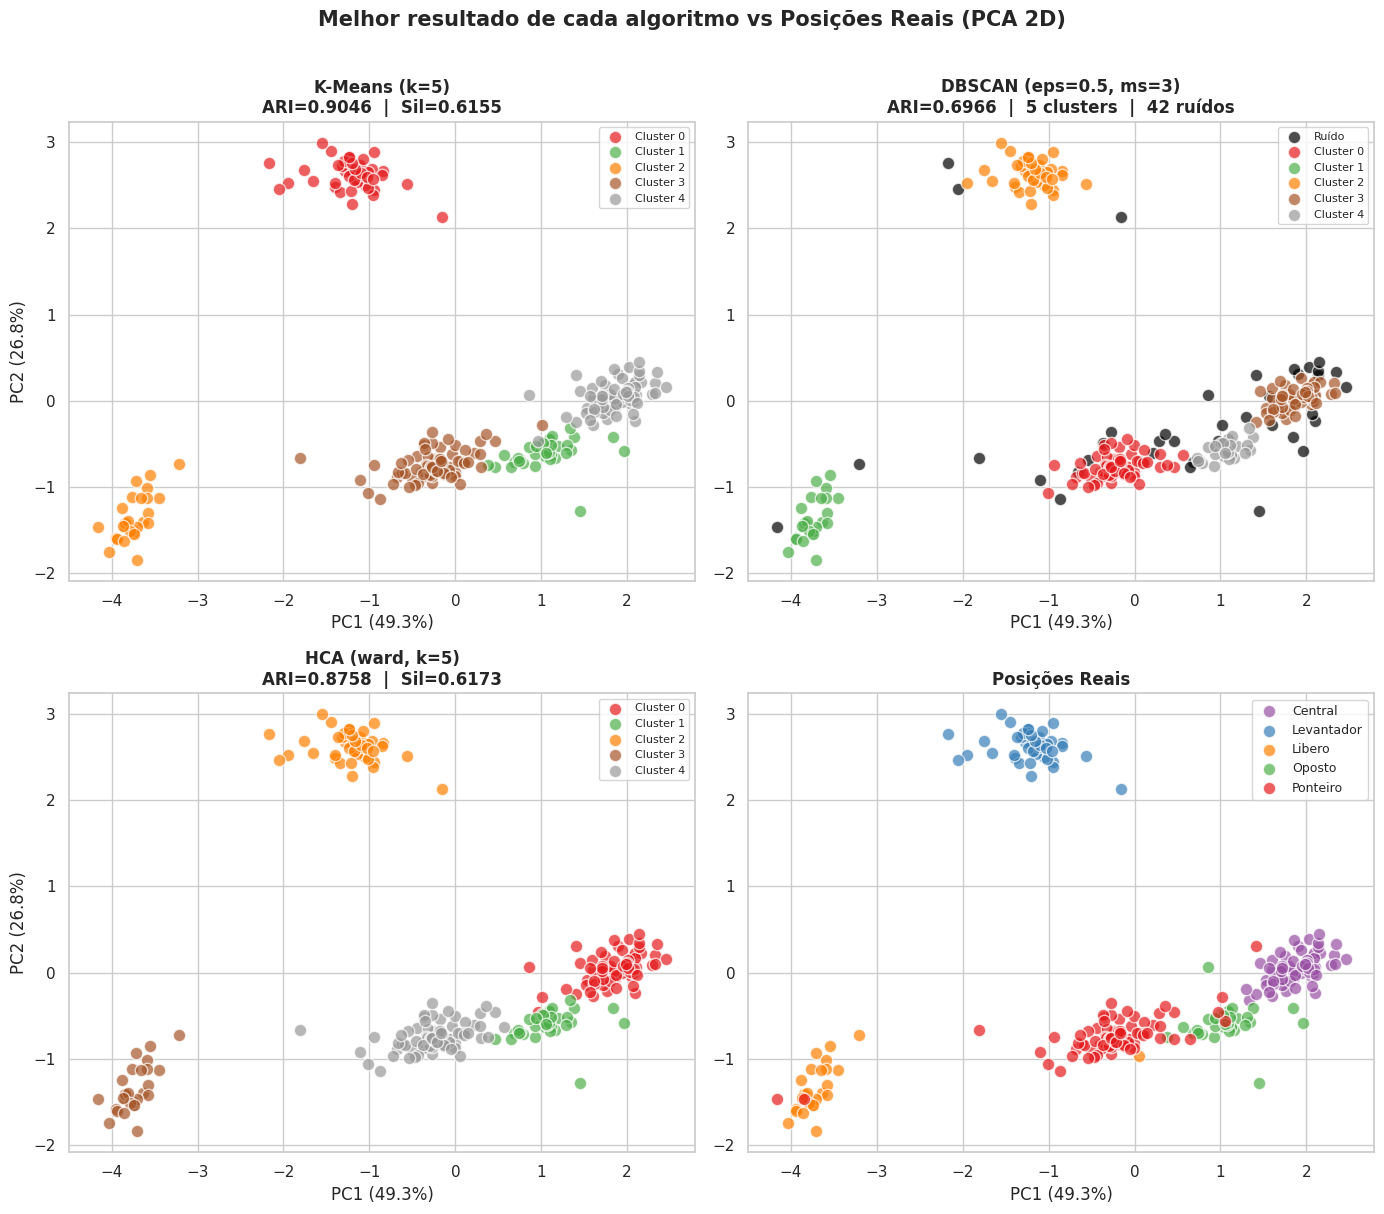

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Performando o PCA para visualização 2D dos clusters
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled_all)

cmap = plt.cm.Set1
pos_uniq = sorted(y.unique())
pc1_label = f'PC1 ({pca.explained_variance_ratio_[0]:.1%})'
pc2_label = f'PC2 ({pca.explained_variance_ratio_[1]:.1%})'

def plot_clusters(ax, labels, title):
    for c in sorted(set(labels)):
        mask = labels == c
        color = 'black' if c == -1 else cmap(c / max(max(labels), 1))
        label = 'Ruído' if c == -1 else f'Cluster {c}'
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   color=color, label=label, alpha=0.7, s=80, edgecolors='w')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(pc1_label)
    ax.legend(fontsize=8, loc='upper right')

# (0,0) K-Means melhor k
plot_clusters(axes[0, 0], resultados_km_k[melhor_k_ari]['labels'],
              f'K-Means (k={melhor_k_ari})\nARI={resultados_km_k[melhor_k_ari]["ARI"]:.4f}  |  Sil={resultados_km_k[melhor_k_ari]["Silhouette"]:.4f}')
axes[0, 0].set_ylabel(pc2_label)

# (0,1) DBSCAN melhor config
plot_clusters(axes[0, 1], labels_db,
              f"DBSCAN (eps={melhor_db['eps']}, ms={melhor_db['min_samples']})\n"
              f"ARI={ari_db:.4f}  |  {melhor_db['n_clusters']} clusters  |  {melhor_db['n_ruido']} ruídos")

# (1,0) HCA melhor k
plot_clusters(axes[1, 0], resultados_hca_k[melhor_k_hca]['labels'],
              f'HCA (ward, k={melhor_k_hca})\nARI={resultados_hca_k[melhor_k_hca]["ARI"]:.4f}  |  Sil={resultados_hca_k[melhor_k_hca]["Silhouette"]:.4f}')
axes[1, 0].set_ylabel(pc2_label)

# (1,1) Posições reais
for pos in pos_uniq:
    mask = y == pos
    axes[1, 1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                       color=cores_posicao.get(pos, 'gray'),
                       label=pos, alpha=0.7, s=80, edgecolors='w')
axes[1, 1].set_title('Posições Reais', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel(pc1_label)
axes[1, 1].legend(fontsize=9, loc='upper right')

plt.suptitle('Melhor resultado de cada algoritmo vs Posições Reais (PCA 2D)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Análise dos resultados

Os quatro painéis comparam a melhor configuração de cada algoritmo com as posições reais (PC1 e PC2 explicam juntos ~76% da variância). K-Means e HCA usam `k=5`, diretamente comparáveis às cinco posições.

No painel real, o eixo PC1 já ordena as posições da esquerda para a direita: Líbero no canto inferior esquerdo, Levantador destacado no topo (via PC2), e o trio ofensivo ocupando a grande massa à direita, com o Ponteiro mais ao centro e o Central no extremo direito. Líbero e Levantador aparecem como nuvens compactas e nitidamente descoladas do restante, e os três algoritmos as recuperam sem erro.

K-Means (ARI = 0.9046) e HCA (ARI = 0.8758) reproduzem o painel real quase fielmente, particionando a massa ofensiva em três grupos coerentes com Ponteiro, Oposto e Central. As partições dos dois algoritmos são visualmente muito parecidas entre si e próximas da referência, com os poucos erros restantes na região onde as três posições ofensivas se encostam.

O DBSCAN também encontra os 5 grupos, mas deixa 42 atletas sem classificação (pontos pretos), o que explica seu ARI inferior mesmo acertando o número de clusters. É a manifestação visual da dificuldade prevista pela Hipótese 2.

# 12. Conclusões

Os três algoritmos apresentaram comportamento notavelmente similar: todos recuperaram Levantador e Líbero com pureza quase total, e todos concordaram em `k=5` como a granularidade que melhor descreve os dados. A diferença entre eles está mais na forma de lidar com a fronteira entre as posições ofensivas (Ponteiro, Oposto e Central) do que no resultado final: o K-Means e a HCA classificam esses atletas em clusters coerentes com pequenos erros na zona de contato, enquanto o DBSCAN deixa parte deles sem classificação. A HCA ainda acrescenta uma leitura que os outros dois não expõem, revelando a hierarquia de proximidade entre as posições diretamente no dendrograma, com Levantador e Líbero separando-se do trio ofensivo em alturas de fusão elevadas.

Entre os três, K-Means e HCA se destacam como os melhores candidatos para este dataset: ambos superaram com folga a meta de 0,70, atingindo ARI de 0.9046 e 0.8758 respectivamente com `k=5`, além de clusters coesos (Silhouette ≈ 0,62). O DBSCAN, apesar de acertar o número de grupos e ser útil para revelar a estrutura de densidade dos dados, ficou limitado pelo descarte de 42 atletas como ruído, o que reduziu seu ARI para 0.6966.

O principal resultado deste estudo demonstra que o dataset apresenta uma estrutura capaz de distinguir consistentemente as cinco posições táticas do voleibol a partir apenas do volume relativo dos fundamentos. Levantador e Líbero são identificados de forma quase perfeita, por terem discriminadores praticamente exclusivos (`p_v_Set` e `p_v_Receive`), enquanto a única fonte de erro relevante está na sobreposição entre Ponteiro, Oposto e Central, posições que compartilham o volume de ataque e só se distinguem pela combinação de recepção e bloqueio. Que três algoritmos com lógicas matemáticas distintas convirjam de forma independente para `k=5`, o número exato de posições oficiais, é a evidência mais forte de que essas funções táticas correspondem a grupos reais e bem definidos no espaço de features.

## 12.2 Limitações do estudo

1. **Escopo temporal restrito:** o dataset cobre exclusivamente a VNL 2024 masculina. Estilos táticos e composições de elenco variam entre edições e ligas nacionais, o que limita a generalização dos clusters encontrados a contextos não vistos.

2. **Features limitadas ao volume de jogo:** as 6 variáveis `p_v_*` capturam apenas a proporção de participação em cada fundamento. A inclusão de dados de natureza diferente, como métricas biométricas (altura, envergadura, velocidade de salto), poderia introduzir discriminadores adicionais capazes de separar posições que se sobrepõem no espaço atual, como Oposto, Ponteiro e Central.

3. **Escolha do limiar de participação:** o viés dos atletas de baixa participação foi tratado na seção 4.3.1 com um critério de corte de 10 ações, que removeu 5,3% da amostra. Esse limiar é uma escolha discreta: atletas logo abaixo do corte são descartados por completo, e os 15 removidos simplesmente não têm amostra suficiente para serem agrupados de forma confiável, uma limitação do próprio dado exposta pelo feature engineering que aplicamos.

## 12.3 Próximos passos

1. **Incorporar features biométricas**, que poderiam fornecer discriminadores adicionais para separar as posições ofensivas, que se sobrepõem no espaço atual de volume de jogo.

2. **Validação cross-torneio:** aplicar o mesmo pipeline de clusterização a dados de ligas nacionais ou edições anteriores da VNL, para medir se a estrutura de clusters encontrada é estável entre diferentes contextos competitivos.

3. **Tratar a restrição de soma = 1 das proporções:** como as seis features `p_v_*` são frações que sempre somam 1, elas não variam de forma independente (quando uma cresce, as outras necessariamente diminuem), o que contraria um pressuposto da distância euclidiana usada pelos três algoritmos. Aplicar uma transformação de log-ratio (CLR/ILR) antes da clusterização removeria essa amarra, permitindo verificar se os agrupamentos se mantêm estáveis sob uma métrica mais adequada aos dados.